## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Estilo dos gráficos exportados para o relatório (img/)
COR = "#2f5d50"
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e3da",
    "axes.titlelocation": "left",
})

## Load do Dataset

In [2]:
df = pd.read_csv("./dataset/DailyDelhiClimateTrain.csv")

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


## Documentação da Base

| Item | Descrição |
|---|---|
| **Fonte** | Kaggle — *Daily Climate time series data* (sumanthvrao), coletado da API do Weather Underground. Licença CC0. |
| **Descrição** | Clima diário da cidade de Delhi (Índia). |
| **Variável-alvo** | `meantemp` — temperatura média diária, calculada a partir de leituras a cada 3 horas |
| **Unidade** | °C |
| **Frequência** | Diária |
| **Período** | Treino: 01/01/2013 a 01/01/2017 (1.462 obs.) · Teste: 01/01/2017 a 24/04/2017 (114 obs.) |

### Dicionário das variáveis externas

| Variável | Descrição | Unidade | Tipo | Uso |
|---|---|---|---|---|
| `humidity` | Umidade relativa média diária do ar | % | contínua | mantida |
| `wind_speed` | Velocidade média diária do vento | km/h | contínua | mantida |
| `meanpressure` | Pressão atmosférica média diária | hPa | contínua | **excluída** (valores impossíveis, ver abaixo) |

## Qualidade dos Dados

In [3]:
raw = pd.read_csv("./dataset/DailyDelhiClimateTrain.csv", parse_dates=["date"])

print("Valores ausentes por coluna:")
print(raw.isna().sum().to_string())

print("\nLinhas duplicadas:", raw.duplicated().sum())
print("Datas duplicadas:", raw["date"].duplicated().sum())

# Irregularidades temporais: datas faltantes no calendário diário
calendario = pd.date_range(raw["date"].min(), raw["date"].max(), freq="D")
print("\nDias esperados:", len(calendario), "| dias presentes:", raw["date"].nunique())
print("Datas faltantes:", list(calendario.difference(raw["date"])))

# Zeros no vento podem indicar falha de registro
print("\nDias com wind_speed = 0:", (raw["wind_speed"] == 0).sum())

print("\nÚltimas linhas:")
print(raw.tail(2))

Valores ausentes por coluna:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0

Linhas duplicadas: 0
Datas duplicadas: 0

Dias esperados: 1462 | dias presentes: 1462
Datas faltantes: []

Dias com wind_speed = 0: 26

Últimas linhas:
           date   meantemp  humidity  wind_speed  meanpressure
1460 2016-12-31  15.052632      87.0       7.325        1016.1
1461 2017-01-01  10.000000     100.0       0.000        1016.0


In [4]:
# Outliers pela regra do IQR
def outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)]

for col in ["meantemp", "humidity", "wind_speed", "meanpressure"]:
    o = outliers_iqr(raw[col])
    faixa = f"(de {o.min():.1f} a {o.max():.1f})" if len(o) else ""
    print(f"{col}: {len(o)} outliers {faixa}")

# A pressão ao nível do mar fica entre ~990 e 1030 hPa
print("\nmeanpressure fora do IQR:", sorted(outliers_iqr(raw["meanpressure"]).round(0)))

meantemp: 0 outliers 
humidity: 2 outliers (de 13.4 a 15.9)
wind_speed: 30 outliers (de 17.9 a 42.2)
meanpressure: 9 outliers (de -3.0 a 7679.3)

meanpressure fora do IQR: [-3.0, 12.0, 310.0, 634.0, 938.0, 946.0, 1350.0, 1353.0, 7679.0]


**Interpretação:**
- Não há valores ausentes, linhas ou datas duplicadas, nem datas faltantes: a frequência diária é contínua.
- `wind_speed` tem 26 dias com valor exatamente 0, que podem ser falhas de registro. Foram mantidos porque vento calmo é plausível.
- `meantemp` não tem outliers. Em `humidity` há 2 (13–16%) e em `wind_speed` há 30 (18–42 km/h), todos fisicamente plausíveis e mantidos.
- `meanpressure` tem valores impossíveis (−3, 12, 310, 634, 1.350 e 7.679 hPa), sinal de erro de coleta. A coluna foi excluída.
- A última linha (01/01/2017) está incompleta (umidade 100, vento 0) e coincide com a primeira data do arquivo de teste.

**Decisões de limpeza e transformação:**
1. Exclusão de `meanpressure`.
2. Remoção da última linha, para não sobrepor treino e teste.
3. Sem transformação da alvo (log/Box-Cox): a série é aditiva e a amplitude do ciclo anual é estável entre os anos.

## Limpeza

In [5]:
df = df.drop(columns=["meanpressure"])
df["date"] = pd.to_datetime(df["date"]) 
df = df.set_index("date")

# Remove a última linha (2017-01-01): registro incompleto (umidade 100, vento 0)
# e a data já é o início do dataset de teste
df = df.iloc[:-1]

df.head()

,meantemp,humidity,wind_speed
date,,,
2013-01-01,10.000000,84.500000,0.000000
2013-01-02,7.400000,92.000000,2.980000
2013-01-03,7.166667,87.000000,4.633333
2013-01-04,8.666667,71.333333,1.233333
2013-01-05,6.000000,86.833333,3.700000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2013-01-01 to 2016-12-31
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   meantemp    1461 non-null   float64
 1   humidity    1461 non-null   float64
 2   wind_speed  1461 non-null   float64
dtypes: float64(3)
memory usage: 45.7 KB


## Representação Visual da Série

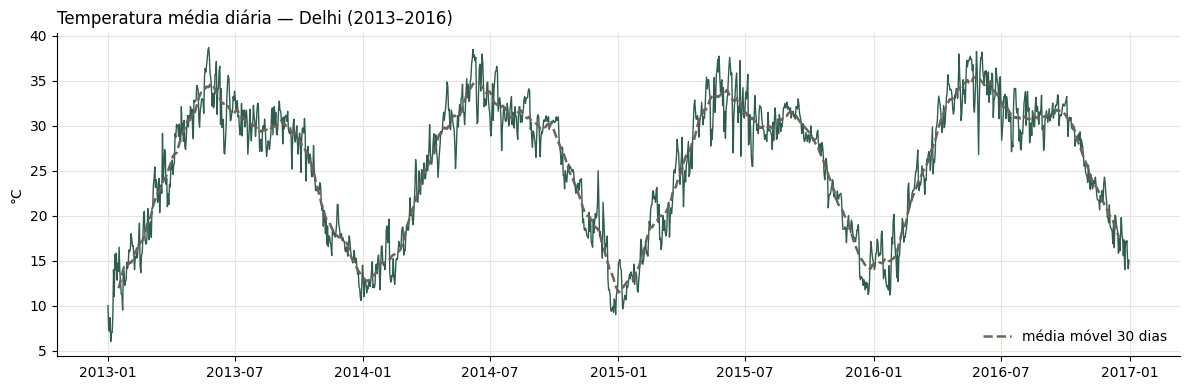

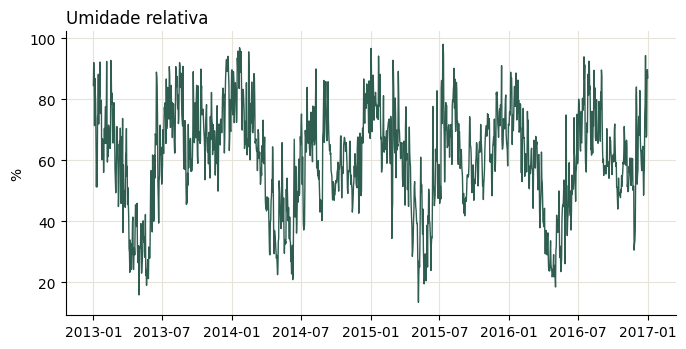

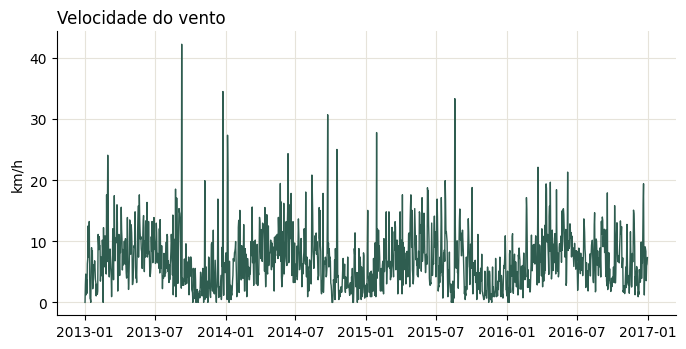

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["meantemp"], color=COR, lw=1)
ax.plot(df.index, df["meantemp"].rolling(30, center=True).mean(),
        color="#6b6558", ls="--", lw=1.8, label="média móvel 30 dias")
ax.set_title("Temperatura média diária — Delhi (2013–2016)")
ax.set_ylabel("°C")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("img/serie_alvo.png", dpi=150)
plt.show()

for col, titulo, unidade in [("humidity", "Umidade relativa", "%"),
                             ("wind_speed", "Velocidade do vento", "km/h")]:
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.plot(df.index, df[col], color=COR, lw=1)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)
    plt.tight_layout()
    plt.savefig(f"img/{col}.png", dpi=150)
    plt.show()

In [8]:
print(df["meantemp"].describe().round(2).to_string())

print("\nMédia anual:")
print(df["meantemp"].groupby(df.index.year).mean().round(2).to_string())

print("\nMédia mensal:")
print(df["meantemp"].groupby(df.index.month).mean().round(1).to_string())

print("\nCorrelação com meantemp:")
print(df.corr()["meantemp"].round(2).to_string())

count    1461.00
mean       25.51
std         7.34
min         6.00
25%        18.86
50%        27.71
75%        31.31
max        38.71

Média anual:
date
2013    24.79
2014    25.01
2015    25.11
2016    27.10

Média mensal:
date
1     13.3
2     17.6
3     22.9
4     29.4
5     33.3
6     33.7
7     31.0
8     30.6
9     30.4
10    27.1
11    20.7
12    15.7

Correlação com meantemp:
meantemp      1.00
humidity     -0.57
wind_speed    0.31


**Interpretação:**
- A temperatura tem média de 25,5 °C e varia de 6 °C (jan/2013) a 38,7 °C (mai/2013).
- O ciclo anual domina: mínimo em janeiro (≈ 13 °C), máximo em maio–junho (≈ 33–34 °C) e um patamar de ~30–31 °C de julho a setembro (monção).
- A média anual fica em ~25 °C de 2013 a 2015 e sobe para 27,1 °C em 2016.
- **Umidade** tem correlação de −0,57 com a temperatura: é mínima em abril–junho e máxima no inverno e na monção.
- **Vento** tem correlação de +0,31: é mais forte no verão, com picos isolados de até 42 km/h.

## Decomposição STL

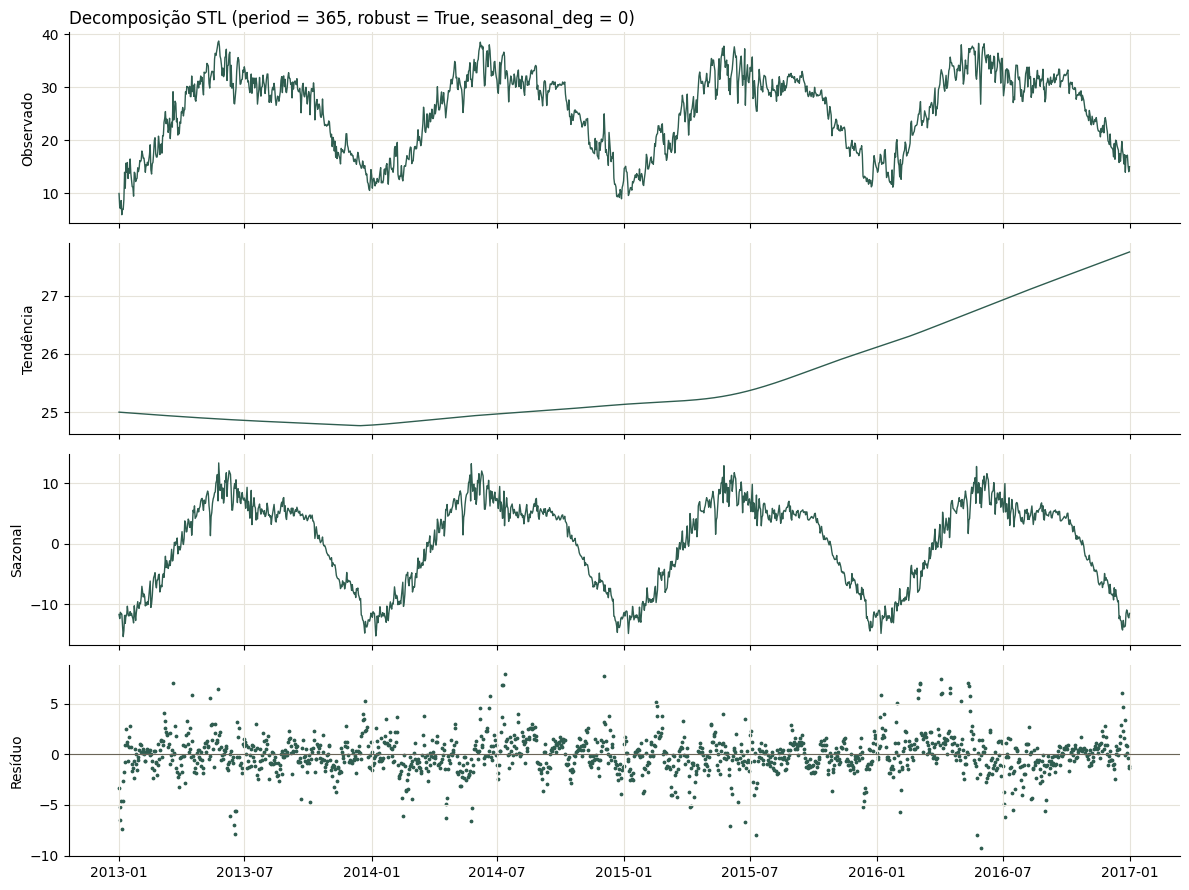

In [9]:
# Série diária com ciclo anual: 365 observações por ciclo
m = 365

# seasonal_deg=0: com só 4 ciclos, cada subsérie sazonal tem 4 pontos; o ajuste
# localmente constante evita que a sazonal absorva o ruído do 1º e do último ano
stl = STL(
    df["meantemp"],
    period=m,
    robust=True,
    seasonal_deg=0
).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
componentes = [("Observado", stl.observed), ("Tendência", stl.trend),
               ("Sazonal", stl.seasonal)]
for ax, (nome, serie) in zip(axes, componentes):
    ax.plot(serie.index, serie, color=COR, lw=1)
    ax.set_ylabel(nome)
axes[3].scatter(stl.resid.index, stl.resid, s=3, color=COR)
axes[3].axhline(0, color="#6b6558", lw=0.8)
axes[3].set_ylabel("Resíduo")
axes[0].set_title("Decomposição STL (period = 365, robust = True, seasonal_deg = 0)")
plt.tight_layout()
plt.savefig("img/stl.png", dpi=150)
plt.show()

### Tendência

In [10]:
trend = stl.trend

# Nível da tendência no início de cada trimestre
print(trend.resample("QS").first().round(2).to_string())

# Mudanças de direção: pontos onde a inclinação troca de sinal
inclinacao = np.sign(trend.diff())
mudancas = inclinacao[inclinacao.diff().fillna(0) != 0]
print("\nMudanças de direção:", [d.strftime("%d/%m/%Y") for d in mudancas.index])
print(f"Mínimo da tendência: {trend.min():.2f} °C em {trend.idxmin():%d/%m/%Y}")

# Inclinação média (°C por mês) em cada fase
fases = {
    "jan/2013 – dez/2013": ("2013-01-01", "2013-12-15"),
    "dez/2013 – mai/2015": ("2013-12-15", "2015-05-31"),
    "jun/2015 – dez/2016": ("2015-06-01", "2016-12-31"),
}
print()
for nome, (ini, fim) in fases.items():
    delta = trend[fim] - trend[ini]
    meses = (pd.Timestamp(fim) - pd.Timestamp(ini)).days / 30.44
    print(f"{nome}: {trend[ini]:.2f} → {trend[fim]:.2f} °C "
          f"(Δ = {delta:+.2f} °C, {delta / meses:+.3f} °C/mês)")

date
2013-01-01    25.00
2013-04-01    24.93
2013-07-01    24.86
2013-10-01    24.81
2014-01-01    24.78
2014-04-01    24.88
2014-07-01    24.97
2014-10-01    25.05
2015-01-01    25.14
2015-04-01    25.20
2015-07-01    25.37
2015-10-01    25.74
2016-01-01    26.11
2016-04-01    26.50
2016-07-01    26.93
2016-10-01    27.34
Freq: QS-JAN

Mudanças de direção: ['16/12/2013']
Mínimo da tendência: 24.77 °C em 15/12/2013

jan/2013 – dez/2013: 25.00 → 24.77 °C (Δ = -0.23 °C, -0.020 °C/mês)
dez/2013 – mai/2015: 24.77 → 25.29 °C (Δ = +0.52 °C, +0.030 °C/mês)
jun/2015 – dez/2016: 25.29 → 27.75 °C (Δ = +2.46 °C, +0.129 °C/mês)


**Interpretação da tendência:**
- **Queda leve (jan/2013 – dez/2013):** a tendência cai de 25,0 para 24,8 °C (−0,2 °C). Na prática, é quase estável.
- **Mudança de direção (dez/2013):** o mínimo da tendência (24,77 °C) ocorre em 15/12/2013, e a partir daí ela passa a subir.
- **Crescimento lento, quase estável (dez/2013 – mai/2015):** +0,5 °C em ~17 meses.
- **Aceleração (meados de 2015):** a inclinação aumenta, mas sem troca de sinal.
- **Crescimento forte e contínuo (jun/2015 – dez/2016):** de 25,3 para 27,7 °C (+2,5 °C em ~19 meses), acompanhando o ano excepcionalmente quente de 2016.
- A variação total (~3 °C) é pequena perto da amplitude sazonal (~22 °C). Com só 4 ciclos, não dá para separar tendência de longo prazo de variação entre anos.

### Sazonalidade e Resíduo

In [11]:
seasonal = stl.seasonal
residual = stl.resid

# Perfil médio da sazonal por mês
print("Componente sazonal média por mês (°C):")
print(seasonal.groupby(seasonal.index.month).mean().round(1).to_string())

# Suavizada em 30 dias para tirar o ruído diário que sobra na sazonal
s30 = seasonal.rolling(30, center=True).mean()
print(f"\nSazonal suavizada: mín {s30.min():.1f} °C ({s30.idxmin():%d/%m/%Y}), "
      f"máx {s30.max():.1f} °C ({s30.idxmax():%d/%m/%Y}), "
      f"amplitude {s30.max() - s30.min():.1f} °C")
print(f"Sazonal diária: mín {seasonal.min():.1f} °C, máx {seasonal.max():.1f} °C")

print(f"\nResíduo: média {residual.mean():.3f}, desvio-padrão {residual.std():.2f} °C")
print("Desvio-padrão por ano:", residual.groupby(residual.index.year).std().round(2).to_dict())
print(f"Mín {residual.min():.1f} °C, máx {residual.max():.1f} °C")
n_ext = (residual.abs() > 3 * residual.std()).sum()
print(f"Dias com |resíduo| > 3 dp: {n_ext} ({n_ext / len(residual):.1%})")
print(f"ADF p-valor: {adfuller(residual)[1]:.1e} | KPSS estatística: {kpss(residual)[0]:.3f}")

Componente sazonal média por mês (°C):
date
1    -11.8
2     -7.6
3     -2.8
4      3.9
5      7.7
6      8.6
7      5.7
8      5.1
9      4.9
10     1.4
11    -5.1
12   -10.4

Sazonal suavizada: mín -12.6 °C (02/01/2014), máx 9.5 °C (05/06/2013), amplitude 22.0 °C
Sazonal diária: mín -15.4 °C, máx 13.3 °C

Resíduo: média -0.042, desvio-padrão 1.90 °C
Desvio-padrão por ano: {2013: 1.83, 2014: 1.89, 2015: 1.68, 2016: 2.13}
Mín -9.2 °C, máx 7.9 °C
Dias com |resíduo| > 3 dp: 36 (2.5%)
ADF p-valor: 9.9e-19 | KPSS estatística: 0.066


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_16956\2381602198.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(f"ADF p-valor: {adfuller(residual)[1]:.1e} | KPSS estatística: {kpss(residual)[0]:.3f}")


**Interpretação da sazonalidade:**
- O ciclo é anual, grande e regular. Suavizada, a sazonal vai de ≈ −12,6 °C (início de janeiro) a ≈ +9,5 °C (início de junho), uma amplitude de ~22 °C. Nos valores diários os extremos chegam a −15,4 e +13,3 °C porque parte do ruído fica na sazonal (há poucos ciclos para suavizá-la).
- O formato é assimétrico e se repete nos quatro anos: subida gradual de janeiro a maio, pico antes da monção, patamar de julho a setembro (≈ +5 °C) e queda rápida de outubro a dezembro.

**Interpretação do resíduo:**
- Centrado em zero, com desvio-padrão de ~1,9 °C e variância parecida entre os anos (1,7 a 2,1 °C).
- Sem padrão sazonal visível. ADF e KPSS concordam que é estacionário.
- Há picos isolados de até −9 e +8 °C (frentes frias, ondas de calor, chuva forte). Cerca de 36 dias (2,5%) passam de 3 desvios-padrão.

### Força da Tendência e da Sazonalidade

$F_S = \max\left(0,\ 1 - \dfrac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}\right) \qquad F_T = \max\left(0,\ 1 - \dfrac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}\right)$

In [12]:
trend = stl.trend
seasonal = stl.seasonal
residual = stl.resid

forca_sazonalidade = max(
    0,
    1 - (
        np.var(residual) /
        np.var(seasonal + residual)
    )
)

forca_tendencia = max(
    0,
    1 - (
        np.var(residual) /
        np.var(trend + residual)
    )
)

# Resultados
print(f'Força da Sazonalidade: {forca_sazonalidade:.4f}')
print(f'Força da Tendência: {forca_tendencia:.4f}')

Força da Sazonalidade: 0.9319
Força da Tendência: 0.1915


**Interpretação:**
- A **sazonalidade anual é muito forte** (F_S ≈ 0,93): quase toda a variação da temperatura é explicada pelo ciclo verão/inverno, que deve ser modelado explicitamente.
- A **tendência é fraca** (F_T ≈ 0,19): explica pouco além do resíduo.
- Obs.: com `period=12` o STL procuraria um ciclo de 12 dias, que não existe, e o ciclo anual seria absorvido pela tendência, invertendo as conclusões.

## Testes de Estacionariedade

In [13]:
# Funções
def test_adf(x):
    res = adfuller(x)

    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4],
    }

    print('ADF')

    for k, v in results.items():
        print(f' {k}: {v}')

def test_kpss(x):
    res = kpss(x)

    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3],
    }

    print('KPSS')

    for k, v in results.items():
        print(f' {k}: {v}')

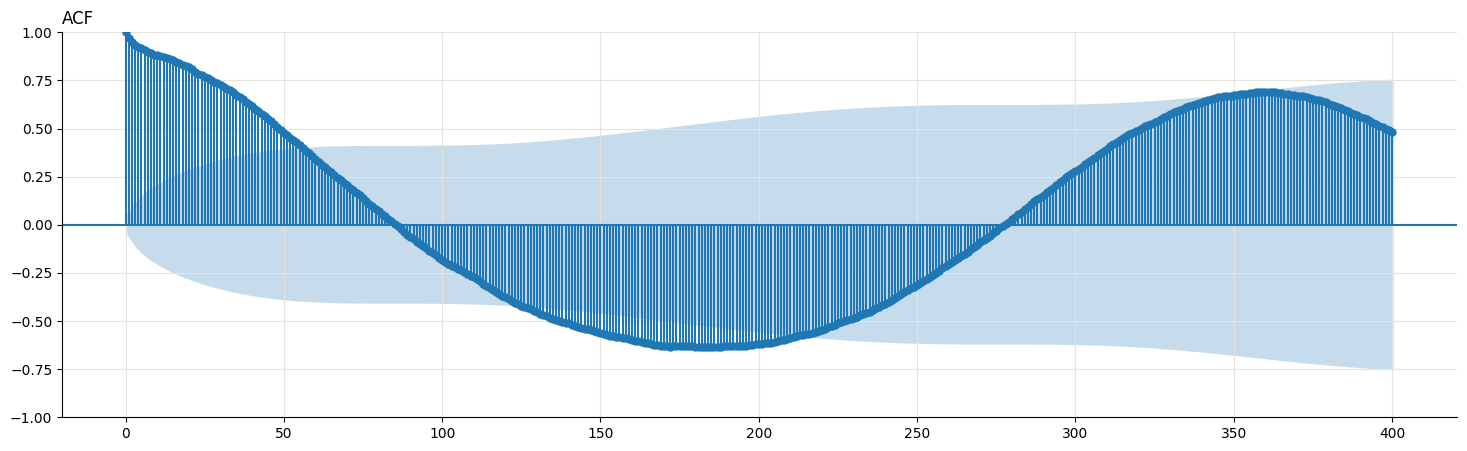

ADF
 ADF Statistic: -2.155565227446429
 p-value: 0.22276593986733573
 Critical Values 1/5/10%: {'1%': np.float64(-3.4348678719530934), '5%': np.float64(-2.863535337271721), '10%': np.float64(-2.5678323015457787)}

KPSS
 KPSS Statistic: 0.19176382197969408
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_16956\2300485443.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x)


In [14]:
# 400 lags para enxergar o ciclo anual (lag 365)
fig, ax = plt.subplots(figsize=(18,5))
plot_acf(df["meantemp"], lags=400, ax=ax)
ax.set_title('ACF')
plt.show()

test_adf(df["meantemp"])
print()
test_kpss(df["meantemp"])

**Interpretação:**
- **ADF** não rejeita H0 (p > 0.05) → indicaria raiz unitária (não estacionária).
- **KPSS** não rejeita H0 (estatística < valor crítico de 10%) → indicaria estacionariedade.
- Os testes **discordam**. A ACF mostra uma onda senoidal (negativa perto do lag 182, positiva perto do lag 365): a persistência vem de uma **sazonalidade anual determinística forte**, e não necessariamente de uma raiz unitária. Esse tipo de padrão reduz o poder do ADF.

## Diferenciação

ADF
 ADF Statistic: -16.520440592332665
 p-value: 2.0666135559466146e-29
 Critical Values 1/5/10%: {'1%': np.float64(-3.4348678719530934), '5%': np.float64(-2.863535337271721), '10%': np.float64(-2.5678323015457787)}

KPSS
 KPSS Statistic: 0.14703290223179305
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\karinamartins-ieg\AppData\Local\Temp\ipykernel_16956\2300485443.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(x)


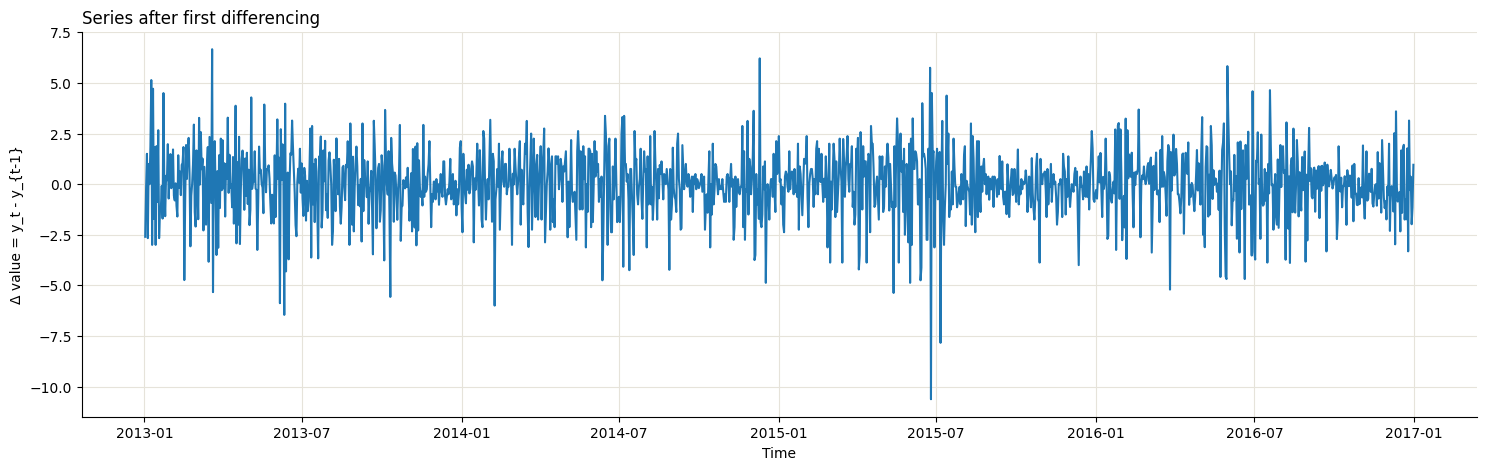

In [15]:
diff = df["meantemp"].diff(1).dropna()

adf_diff = test_adf(diff)
print()
kpss_diff = test_kpss(diff)

plt.figure(figsize=(18,5))
plt.plot(diff.index, diff.values)

plt.title('Series after first differencing')
plt.xlabel('Time')
plt.ylabel('Δ value = y_t - y_{t-1}')

plt.show()

**Interpretação:**
- Após a 1ª diferença, o ADF rejeita H0 com folga e o KPSS não rejeita → a série diferenciada é **estacionária** (d = 1).
- A diferença de 1ª ordem **não remove a sazonalidade anual**, apenas a atenua. A diferenciação sazonal (lag 365) custaria 1 dos 4 anos de dados, então não compensa.
- Alternativas para tratar a sazonalidade: termos de Fourier como exógenas (ARIMAX), Prophet, ou modelar o resíduo do STL(365).

## Análise de ACF e PACF 

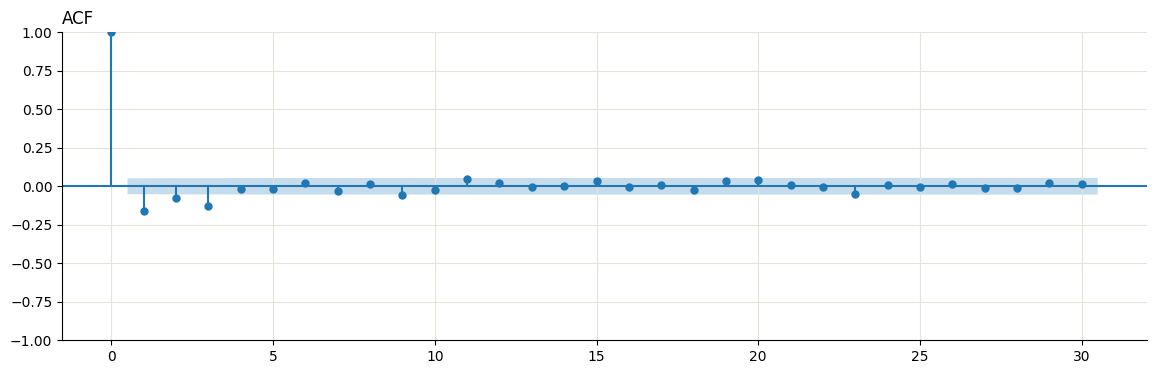

In [16]:
fig, ax = plt.subplots(figsize=(14,4))
plot_acf(diff, lags=30, ax=ax)
ax.set_title('ACF')
plt.show()

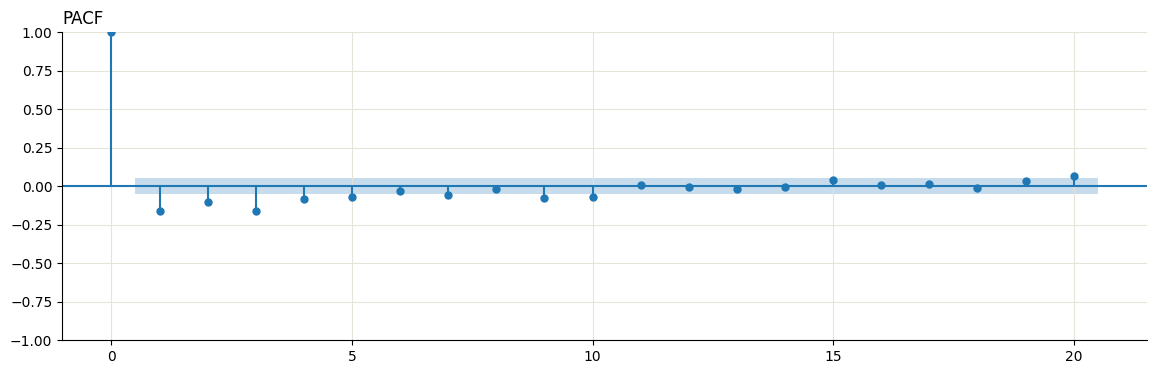

In [17]:
MAX_LAG = 20

fig, ax = plt.subplots(figsize=(14,4))
plot_pacf(diff, lags=MAX_LAG, ax=ax, title="PACF")
plt.show()

**Interpretação** (limite de significância ≈ ±1.96/√n ≈ ±0.05):
- **ACF**: negativa e significativa nos lags 1 a 3 (≈ −0.16, −0.08, −0.13) e depois próxima de zero → sugere componente **MA** com q entre 1 e 3.
- **PACF**: negativa e decaindo aos poucos ao longo dos primeiros lags → também é característico de processo **MA**.
- Modelos candidatos: **ARIMA(0,1,1)**, **ARIMA(0,1,3)**, **ARIMA(1,1,1)** e **ARIMA(3,1,0)**, comparados por AIC/BIC e validados com o teste de Ljung-Box nos resíduos.

## Feature Engineering

**Horizonte: `h = 1` dia.** A previsão do dia *t* é feita no fim do dia *t−1*, então toda feature da linha *t* usa só informação até *t−1*. Nenhuma coluna usa o valor do próprio dia *t*, nem da temperatura nem das externas, porque essa informação não existe na hora da previsão.

| Tipo | Features |
|---|---|
| Lags do alvo | temperatura de 1 a 7 dias atrás (todos os lags da última semana), 14 e 30 dias atrás |
| Janelas móveis do alvo | média, desvio-padrão, mínimo e máximo dos últimos 7 e 30 dias |
| Outras | variação de ontem em relação a anteontem |
| Calendário / encoding cíclico | seno e cosseno do dia do ano (ciclo anual), conhecidos antecipadamente |
| Externas defasadas | `humidity` e `wind_speed` de 1 a 7 dias atrás |

As externas são testadas em três conjuntos, mais um controle sem externas:
- **ontem:** lag 1;
- **ontem + anteontem:** lags 1 e 2;
- **semana:** lags 1 a 7.

Dia da semana e feriados não entram: não há motivo físico para a temperatura seguir o calendário civil.

In [18]:
# h = 1: a linha t só pode usar informação até t-1
H = 1
EXTERNAS = ["humidity", "wind_speed"]
LAGS_ALVO = [1, 2, 3, 4, 5, 6, 7, 14, 30]
JANELAS = [7, 30]
MAX_LAG_EXTERNAS = 7

teste = pd.read_csv("./dataset/DailyDelhiClimateTest.csv", parse_dates=["date"], index_col="date")
teste = teste.drop(columns=["meanpressure"])

# Treino + teste numa série só, para que os lags do início do teste usem o fim do treino
serie = pd.concat([df, teste]).asfreq("D")
assert serie.notna().all().all()


def montar_features(serie):
    base = pd.DataFrame(index=serie.index)
    base["y"] = serie["meantemp"]

    for l in LAGS_ALVO:
        base[f"temp_lag{l}"] = serie["meantemp"].shift(l)

    # shift(1) antes do rolling para a janela terminar em t-1
    passado = serie["meantemp"].shift(1)
    for w in JANELAS:
        base[f"temp_media{w}"] = passado.rolling(w).mean()
        base[f"temp_dp{w}"] = passado.rolling(w).std()
        base[f"temp_min{w}"] = passado.rolling(w).min()
        base[f"temp_max{w}"] = passado.rolling(w).max()

    base["temp_var1"] = base["temp_lag1"] - base["temp_lag2"]

    # Calendário é conhecido antecipadamente, pode usar o próprio dia t
    dia_ano = serie.index.dayofyear
    base["doy_sin"] = np.sin(2 * np.pi * dia_ano / 365.25)
    base["doy_cos"] = np.cos(2 * np.pi * dia_ano / 365.25)

    for c in EXTERNAS:
        for l in range(1, MAX_LAG_EXTERNAS + 1):
            base[f"{c}_lag{l}"] = serie[c].shift(l)

    return base


base = montar_features(serie)
base["teste"] = base.index >= teste.index[0]

FEATURES_ALVO = [c for c in base.columns if c.startswith("temp_")]
FEATURES_CALENDARIO = ["doy_sin", "doy_cos"]


def lags_externas(n):
    return [f"{c}_lag{l}" for c in EXTERNAS for l in range(1, n + 1)]


CONJUNTOS_EXTERNAS = {
    "sem externas": [],
    "ontem (lag 1)": lags_externas(1),
    "ontem + anteontem (lags 1-2)": lags_externas(2),
    "semana (lags 1-7)": lags_externas(7),
}
FEATURE_SETS = {nome: FEATURES_ALVO + FEATURES_CALENDARIO + ext
                for nome, ext in CONJUNTOS_EXTERNAS.items()}

for nome, cols in FEATURE_SETS.items():
    print(f"{nome}: {len(cols)} features")
base.head(3).T

sem externas: 20 features
ontem (lag 1): 22 features
ontem + anteontem (lags 1-2): 24 features
semana (lags 1-7): 34 features


date,2013-01-01,2013-01-02,2013-01-03
y,10.0,7.4,7.166667
temp_lag1,NaN,10.0,7.4
temp_lag2,NaN,NaN,10.0
temp_lag3,NaN,NaN,NaN
temp_lag4,NaN,NaN,NaN
temp_lag5,NaN,NaN,NaN
temp_lag6,NaN,NaN,NaN
temp_lag7,NaN,NaN,NaN
temp_lag14,NaN,NaN,NaN
temp_lag30,NaN,NaN,NaN


In [19]:
# Checagem de vazamento: alterar o dia t inteiro (alvo e externas) não pode mudar
# nenhuma feature da linha t, só as das linhas seguintes
todas = FEATURE_SETS["semana (lags 1-7)"]
for t in ["2014-06-15", "2016-12-31", "2017-02-01"]:
    alterada = serie.copy()
    alterada.loc[t] += 100
    nova = montar_features(alterada)
    seguinte = pd.Timestamp(t) + pd.Timedelta(days=1)
    assert np.array_equal(nova.loc[t, todas].to_numpy(float),
                          base.loc[t, todas].to_numpy(float)), f"vazamento em {t}"
    assert not np.array_equal(nova.loc[seguinte, todas].to_numpy(float),
                              base.loc[seguinte, todas].to_numpy(float))
print("Nenhuma feature da linha t depende de valores do dia t.")

Nenhuma feature da linha t depende de valores do dia t.


In [20]:
# NAs gerados pelos lags e janelas: só aparecem no início da série (warm-up)
na = base[todas].isna().sum()
print("NAs por feature (maiores):")
print(na.sort_values(ascending=False).head(5).to_string())

# Mesmo início para todos os conjuntos, para que todos treinem nas mesmas linhas
INICIO = base[todas].dropna().index[0]
print(f"\nPrimeira linha completa: {INICIO:%d/%m/%Y} ({base.index.get_loc(INICIO)} dias de warm-up descartados)")

dados = base.loc[INICIO:]
assert dados[todas].notna().all().all()
print(f"Linhas para modelagem: {(~dados['teste']).sum()} no treino + {dados['teste'].sum()} no teste")

NAs por feature (maiores):
temp_min30      30
temp_lag30      30
temp_dp30       30
temp_media30    30
temp_max30      30

Primeira linha completa: 31/01/2013 (30 dias de warm-up descartados)
Linhas para modelagem: 1431 no treino + 114 no teste


### Teste dos conjuntos de externas

Comparação rápida para decidir quais lags das externas entram, **sem usar o bloco de teste**:
- Random Forest com hiperparâmetros fixos (`n_estimators=300`, `min_samples_leaf=2`). A otimização vem depois, no grid search.
- Dois modos de alvo: **nível**, em que a árvore prevê `y[t]`, e **diferença**, em que prevê `y[t] − y[t−1]` e a previsão é reconstruída somando a temperatura de ontem. Árvores não extrapolam além dos valores vistos no treino, e o modo diferença é a forma usual de contornar isso.
- Walk-forward em 2016: na origem *t*, prevê o dia *t* com `h = 1`. O modelo é reajustado a cada 7 dias com todo o histórico anterior à semana.
- A persistência (amanhã = hoje) entra como referência.
- Também se mostra o MAE em jan–abr/2016, mesma época do ano do bloco de teste.

In [21]:
from sklearn.ensemble import RandomForestRegressor

treino = dados[~dados["teste"]]
ORIGENS_VAL = treino.index[treino.index >= "2016-01-01"]
REFIT = 7


def alvo(linhas, modo):
    return linhas["y"] - linhas["temp_lag1"] if modo == "diferença" else linhas["y"]


def walk_forward_rf(cols, modo):
    previsao = pd.Series(index=ORIGENS_VAL, dtype=float)
    for i in range(0, len(ORIGENS_VAL), REFIT):
        bloco = ORIGENS_VAL[i:i + REFIT]
        hist = treino.loc[:bloco[0] - pd.Timedelta(days=1)]
        rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                   random_state=42, n_jobs=-1)
        rf.fit(hist[cols], alvo(hist, modo))
        p = rf.predict(treino.loc[bloco, cols])
        previsao[bloco] = p + treino.loc[bloco, "temp_lag1"] if modo == "diferença" else p
    return previsao


real = treino.loc[ORIGENS_VAL, "y"]
mesma_epoca = ORIGENS_VAL[ORIGENS_VAL.month <= 4]

previsoes = {"persistência (y[t-1])": treino.loc[ORIGENS_VAL, "temp_lag1"]}
for modo in ["nível", "diferença"]:
    for nome, cols in FEATURE_SETS.items():
        previsoes[f"RF {modo} — {nome}"] = walk_forward_rf(cols, modo)

comparacao = pd.DataFrame({
    "MAE 2016": {k: (real - p).abs().mean() for k, p in previsoes.items()},
    "MAE jan-abr/2016": {k: (real[mesma_epoca] - p[mesma_epoca]).abs().mean()
                         for k, p in previsoes.items()},
}).sort_values("MAE 2016").round(3)
comparacao

,MAE 2016,MAE jan-abr/2016
RF diferença — ontem + anteontem (lags 1-2),1.219,1.094
RF diferença — semana (lags 1-7),1.221,1.110
RF diferença — ontem (lag 1),1.226,1.129
persistência (y[t-1]),1.226,1.123
RF diferença — sem externas,1.242,1.153
RF nível — semana (lags 1-7),1.276,1.211
RF nível — ontem (lag 1),1.278,1.231
RF nível — ontem + anteontem (lags 1-2),1.279,1.202
RF nível — sem externas,1.283,1.257


**Interpretação:**
- **Modo diferença é melhor que nível em todos os conjuntos** (≈ 0,05 °C a menos de MAE). Prever a variação em relação a ontem contorna a incapacidade da árvore de extrapolar e aproveita a persistência forte da temperatura.
- **As externas defasadas ajudam:** no modo diferença, o MAE cai de 1,242 (sem externas) para 1,219 com umidade e vento de ontem e anteontem.
- **A semana inteira não acrescenta nada além dos lags 1–2** (1,221 contra 1,219) e adiciona 10 colunas. Ontem sozinho fica no meio (1,226).
- **A persistência é uma referência difícil de bater com `h = 1`:** com hiperparâmetros padrão, só o RF em diferença com externas fica abaixo dela, e por pouco (1,219 contra 1,226). O grid search precisa superar essa marca, senão o modelo não acrescenta nada em relação a "amanhã = hoje".

**Decisão:** o conjunto padrão das externas passa a ser **ontem + anteontem (lags 1–2)**, com o modo diferença. Os outros conjuntos e o modo nível continuam como opções no grid search.

**Tratamento dos NAs:** os lags e janelas geram NAs só nos 30 primeiros dias (a maior exigência é a janela e o lag de 30 dias). Essas linhas são descartadas (warm-up) e todos os conjuntos usam as mesmas linhas a partir de 31/01/2013. No início do bloco de teste não há NAs, porque os lags usam o fim do treino.

**Uso por modelo:** Random Forest e XGBoost usam a mesma tabela de features. O SARIMAX recebe só as externas defasadas (e, se preciso, o calendário), porque os termos AR/MA já fazem o papel dos lags do alvo. O Holt-Winters é univariado.


## Validação Walk-forward

| Item | Definição |
|---|---|
| **Horizonte** | `h = 1` dia: na origem *t* (fim do dia *t−1*) prevê-se o dia *t* |
| **Janela de treino** | Expansiva: em cada origem o modelo usa todo o histórico anterior a ela |
| **Treino inicial** | 31/01/2013 a 31/12/2015 (após o warm-up de 30 dias das features) |
| **Validação** | 01/01 a 30/04/2016: 121 origens, usadas só para escolher hiperparâmetros |
| **Teste final** | 01/01 a 24/04/2017 (arquivo de teste): 114 origens, usado uma única vez |
| **Passo** | 1 dia: uma previsão por dia, sempre com os valores reais até a véspera |
| **Reajuste** | A cada 7 dias o modelo é reajustado com todo o histórico anterior. Nos dias intermediários ele continua prevendo 1 dia à frente com os dados reais que vão chegando, mas sem reestimar os coeficientes. |

**Por que jan–abr/2016 na validação:** é a mesma época do ano do teste (subida da temperatura depois do inverno). O MAE de validação fica comparável ao que se espera no teste.

**Regras que valem para os 4 modelos:**
- Mesmas origens, mesmo horizonte, mesmo bloco de teste e mesmo calendário de reajuste.
- Hiperparâmetros escolhidos só na validação e mantidos fixos no teste.
- Na origem *t*, nada do dia *t* em diante entra no ajuste. As features da linha *t* já usam só informação até *t−1* (checado na seção anterior).
- Os modelos estatísticos (SARIMAX e Holt-Winters) preveem os dias intermediários com a filtragem 1 passo à frente, com os parâmetros fixos do último reajuste.

In [22]:
REFIT = 7

ORIGENS_VALIDACAO = dados.index[(dados.index >= "2016-01-01") & (dados.index <= "2016-04-30")]
ORIGENS_TESTE = dados.index[dados["teste"]]

# Sanidade do protocolo
assert len(ORIGENS_VALIDACAO) == 121 and len(ORIGENS_TESTE) == 114
assert ORIGENS_VALIDACAO.max() < ORIGENS_TESTE.min()
assert (ORIGENS_TESTE == teste.index).all()

for nome, origens in [("Validação", ORIGENS_VALIDACAO), ("Teste", ORIGENS_TESTE)]:
    treino_ini = dados.loc[:origens[0] - pd.Timedelta(days=1)]
    n_refits = int(np.ceil(len(origens) / REFIT))
    print(f"{nome}: {len(origens)} origens ({origens[0]:%d/%m/%Y} a {origens[-1]:%d/%m/%Y}), "
          f"{n_refits} reajustes")
    print(f"   treino na 1ª origem: {treino_ini.index[0]:%d/%m/%Y} a {treino_ini.index[-1]:%d/%m/%Y} "
          f"({len(treino_ini)} dias)")

Validação: 121 origens (01/01/2016 a 30/04/2016), 18 reajustes
   treino na 1ª origem: 31/01/2013 a 31/12/2015 (1065 dias)
Teste: 114 origens (01/01/2017 a 24/04/2017), 17 reajustes
   treino na 1ª origem: 31/01/2013 a 31/12/2016 (1431 dias)


In [23]:
import time


def walk_forward(prever_bloco, origens, refit=REFIT):
    """Walk-forward com h = 1 e janela expansiva.

    A cada `refit` origens chama prever_bloco(hist, bloco):
    - hist: todas as linhas de `dados` anteriores à primeira data do bloco (treino);
    - bloco: datas a prever. Cada previsão do dia t só pode usar informação até t-1.
    Retorna as previsões, os resíduos (real - previsto) e o tempo total.
    """
    previsao = pd.Series(index=origens, dtype=float)
    inicio = time.perf_counter()
    for i in range(0, len(origens), refit):
        bloco = origens[i:i + refit]
        hist = dados.loc[:bloco[0] - pd.Timedelta(days=1)]
        assert hist.index.max() < bloco[0]
        previsao[bloco] = np.asarray(prever_bloco(hist, bloco), dtype=float)
    assert previsao.notna().all()
    real = dados.loc[origens, "y"]
    return {"previsao": previsao, "residuo": real - previsao,
            "mae": (real - previsao).abs().mean(), "tempo_s": time.perf_counter() - inicio}

### Referência: persistência

A persistência ("amanhã = hoje") não tem parâmetros e entra como piso de comparação. Um modelo que não fique abaixo do MAE dela não acrescenta nada.

In [24]:
def prever_persistencia(hist, bloco):
    return dados.loc[bloco, "temp_lag1"]


persistencia_val = walk_forward(prever_persistencia, ORIGENS_VALIDACAO)
print(f"Persistência — MAE na validação (jan–abr/2016): {persistencia_val['mae']:.3f} °C")

Persistência — MAE na validação (jan–abr/2016): 1.123 °C


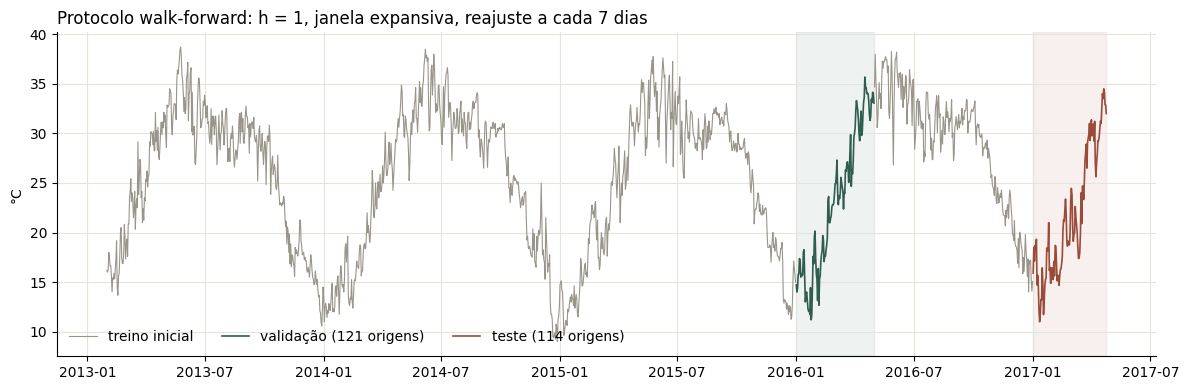

In [25]:
# Linha do tempo do protocolo
fig, ax = plt.subplots(figsize=(12, 4))
treino_ini = dados.loc[:ORIGENS_VALIDACAO[0] - pd.Timedelta(days=1)]
ax.plot(treino_ini.index, treino_ini["y"], color="#9a958a", lw=0.8, label="treino inicial")
entre = dados.loc[ORIGENS_VALIDACAO[-1] + pd.Timedelta(days=1):ORIGENS_TESTE[0] - pd.Timedelta(days=1)]
ax.plot(entre.index, entre["y"], color="#9a958a", lw=0.8)
ax.plot(ORIGENS_VALIDACAO, dados.loc[ORIGENS_VALIDACAO, "y"], color=COR, lw=1.2, label="validação (121 origens)")
ax.plot(ORIGENS_TESTE, dados.loc[ORIGENS_TESTE, "y"], color="#9a4b3a", lw=1.2, label="teste (114 origens)")
for origens, cor in [(ORIGENS_VALIDACAO, COR), (ORIGENS_TESTE, "#9a4b3a")]:
    ax.axvspan(origens[0], origens[-1], color=cor, alpha=0.08)
ax.set_title("Protocolo walk-forward: h = 1, janela expansiva, reajuste a cada 7 dias")
ax.set_ylabel("°C")
ax.legend(frameon=False, loc="lower left", ncol=3)
plt.tight_layout()
plt.savefig("img/walk_forward.png", dpi=150)
plt.show()

**Interpretação:**
- O treino cresce a cada origem: na validação começa com 1.065 dias e, no teste, com 1.431 (todo o treino, inclusive mai–dez/2016, que fica entre a validação e o teste).
- A persistência fica em 1,123 °C na validação. Esse é o piso que SARIMAX, Holt-Winters, Random Forest e XGBoost precisam superar no grid search.
- A escolha das externas na seção anterior se mantém nesta janela: em jan–abr/2016, o RF em diferença com lags 1–2 também foi o melhor (1,094 °C).

## Otimização dos Hiperparâmetros

Critério único para todos os modelos: **MAE do walk-forward nas 121 origens de validação (jan–abr/2016)**. O bloco de teste não é usado para nenhuma decisão. Ele só entra na seção seguinte, com as configurações já fixas.

### Base Models

Modelos de referência simples, construídos como no notebook de referência. Todos fazem a previsão 1 passo à frente, usando só os valores reais até *t−1*, e cada um tem um parâmetro escolhido pela validação:

| Modelo | Previsão do dia *t* | Parâmetro testado |
|---|---|---|
| Média Móvel | média de *y* nos últimos *k* dias | k ∈ {1, 2, 3, 5, 7, 14, 30} |
| Média Acumulada | média de todo o histórico até *t−1* | — |
| EMA | média móvel exponencial até *t−1* | α ∈ {0,1; 0,2; …; 0,9} |
| Seasonal Naive | valor de *s* dias atrás, *y[t−s]* | s ∈ {1, 2, 3, 7, 14, 30, 365} |
| Delta | *y[t−1]* + variação média dos últimos *janela* dias | janela ∈ {1, 2, 3, 7, 14, 30} |

O MAE de treino (01/01/2014 a 31/12/2015, janela comum a todos os parâmetros, inclusive `s = 365`) aparece só como registro. A escolha é sempre pela validação.

In [26]:
y_full = serie["meantemp"]
JANELA_TREINO = (dados.index >= "2014-01-01") & (dados.index <= "2015-12-31")

sumario = {}
previsoes_base = {}


def avaliar_base(nome, rotulo, valores, formula):
    """Testa cada valor do parâmetro e escolhe pelo MAE de validação.

    formula(v) devolve a previsão 1 passo à frente para a série inteira
    (só usa valores até t-1). A validação passa pela mesma função walk_forward
    dos outros modelos.
    """
    linhas = []
    previsoes = {}
    for v in valores:
        previsao = formula(v)
        previsoes[v] = previsao
        val = walk_forward(lambda hist, bloco: previsao[bloco], ORIGENS_VALIDACAO)
        treino_idx = dados.index[JANELA_TREINO]
        mae_treino = (y_full[treino_idx] - previsao[treino_idx]).abs().mean()
        linhas.append({rotulo: v, "MAE treino": mae_treino, "MAE validação": val["mae"]})

    resultado = pd.DataFrame(linhas)
    melhor = resultado.loc[resultado["MAE validação"].idxmin()]
    v = melhor[rotulo]
    v = int(v) if isinstance(v, (float, np.floating)) and float(v).is_integer() and rotulo != "α" else v
    sumario[nome] = {
        "Parâmetro": f"{rotulo}={v}" if rotulo != "-" else "-",
        "MAE treino": melhor["MAE treino"],
        "MAE validação": melhor["MAE validação"],
    }

    previsao = previsoes[melhor[rotulo]]
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(ORIGENS_VALIDACAO, dados.loc[ORIGENS_VALIDACAO, "y"], color=COR, lw=1.5, label="real")
    ax.plot(ORIGENS_VALIDACAO, previsao[ORIGENS_VALIDACAO], color="#9a4b3a", lw=1, ls="--",
            label=f"{nome} {sumario[nome]['Parâmetro']} (MAE val = {melhor['MAE validação']:.3f})")
    ax.set_title(f"{nome}: melhor configuração na validação (jan–abr/2016)")
    ax.set_ylabel("°C")
    ax.legend(frameon=False, loc="upper left")
    plt.tight_layout()
    plt.show()

    return resultado.round(3), previsao

### Média Móvel

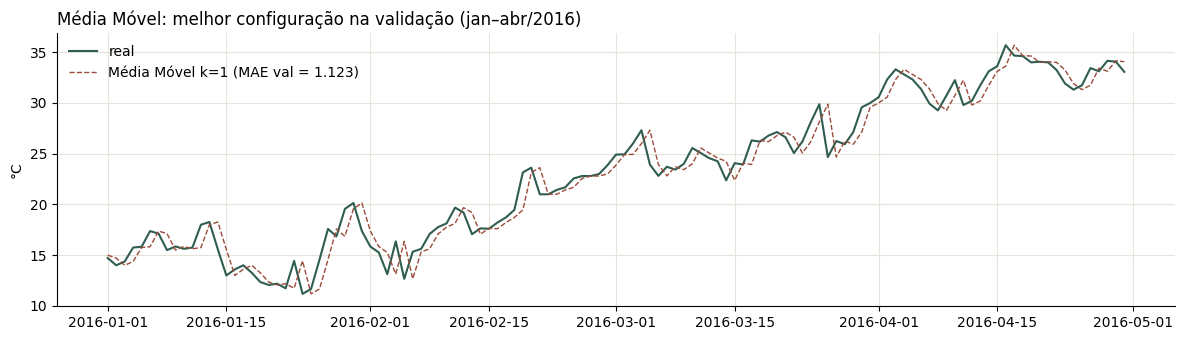

,k,MAE treino,MAE validação
0,1,1.180,1.123
1,2,1.287,1.302
2,3,1.378,1.454
3,5,1.503,1.619
4,7,1.602,1.682
5,14,1.886,1.913
6,30,2.472,2.889


In [27]:
# pred[t] = média(y[t-k] ... y[t-1])
resultado, previsoes_base['Média Móvel'] = avaliar_base(
    'Média Móvel', 'k', [1, 2, 3, 5, 7, 14, 30],
    lambda v: y_full.rolling(v).mean().shift(1),
)
display(resultado)

### Média Acumulada

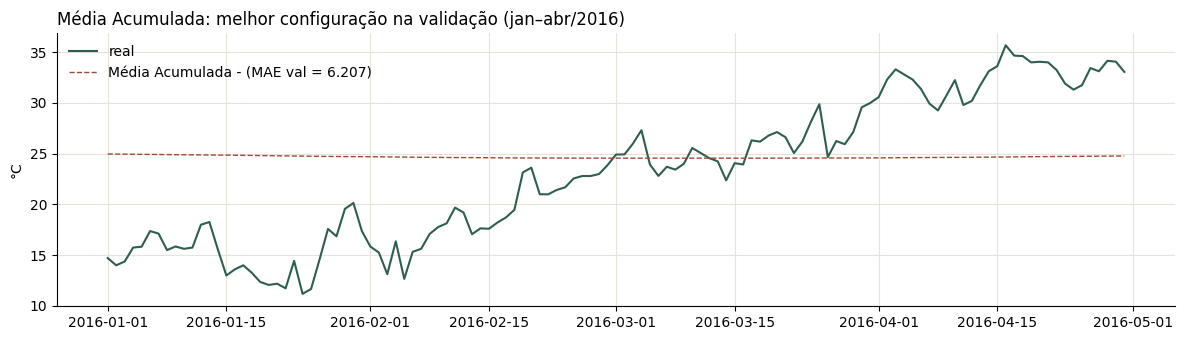

,-,MAE treino,MAE validação
0,None,6.488,6.207


In [28]:
# pred[t] = média(y[0] ... y[t-1])
resultado, previsoes_base['Média Acumulada'] = avaliar_base(
    'Média Acumulada', '-', [None],
    lambda v: y_full.expanding().mean().shift(1),
)
display(resultado)

### EMA

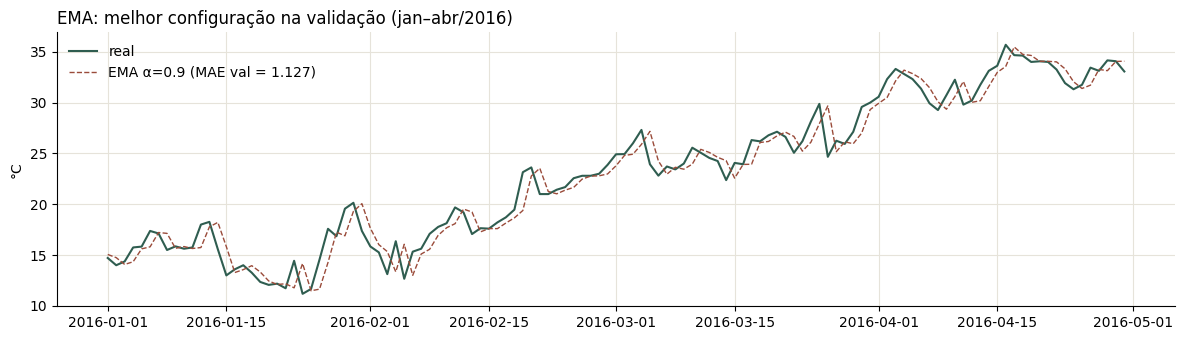

,α,MAE treino,MAE validação
0,0.1,1.919,2.083
1,0.2,1.536,1.586
2,0.3,1.393,1.436
3,0.4,1.311,1.370
4,0.5,1.257,1.301
5,0.6,1.224,1.231
6,0.7,1.202,1.180
7,0.8,1.189,1.141
8,0.9,1.181,1.127


In [29]:
# pred[t] = EMA até t-1
resultado, previsoes_base['EMA'] = avaliar_base(
    'EMA', 'α', list(np.round(np.arange(0.1, 1.0, 0.1), 1)),
    lambda v: y_full.ewm(alpha=v, adjust=False).mean().shift(1),
)
display(resultado)

### Seasonal Naive

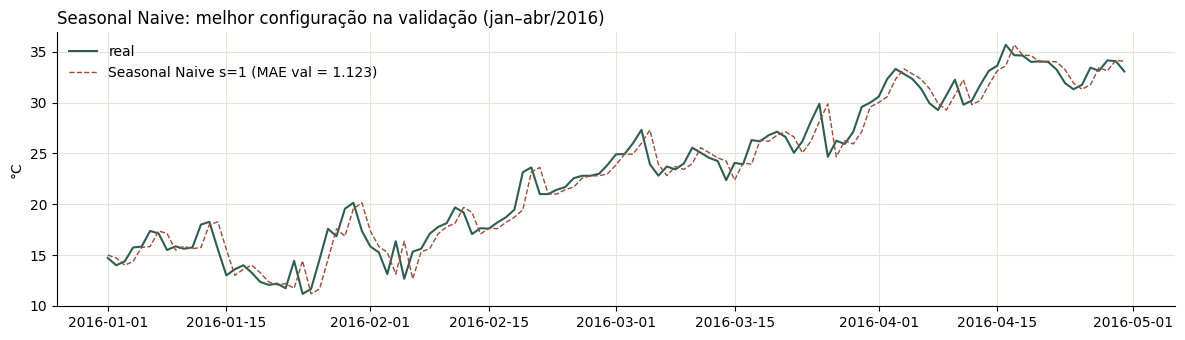

,s,MAE treino,MAE validação
0,1,1.180,1.123
1,2,1.619,1.672
2,3,1.873,1.978
3,7,2.353,2.467
4,14,2.947,3.127
5,30,4.189,4.971
6,365,2.418,3.335


In [30]:
# pred[t] = y[t-s]; s = 1 é a persistência e s = 365 é o mesmo dia do ano anterior
resultado, previsoes_base['Seasonal Naive'] = avaliar_base(
    'Seasonal Naive', 's', [1, 2, 3, 7, 14, 30, 365],
    lambda v: y_full.shift(v),
)
display(resultado)

### Delta

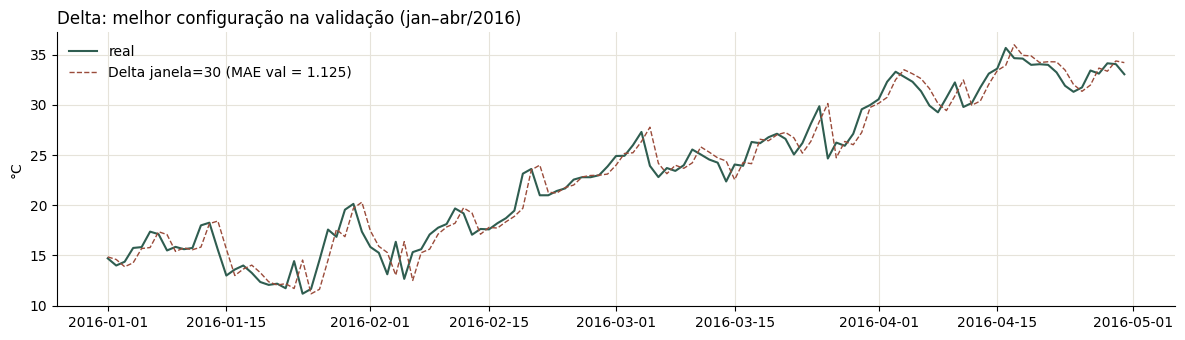

,janela,MAE treino,MAE validação
0,1,1.693,1.596
1,2,1.524,1.391
2,3,1.434,1.348
3,7,1.276,1.232
4,14,1.220,1.131
5,30,1.191,1.125


In [31]:
# pred[t] = y[t-1] + (y[t-1] - y[t-1-janela]) / janela
resultado, previsoes_base['Delta'] = avaliar_base(
    'Delta', 'janela', [1, 2, 3, 7, 14, 30],
    lambda v: y_full.shift(1) + (y_full.shift(1) - y_full.shift(1 + v)) / v,
)
display(resultado)

### Comparativo dos Base Models

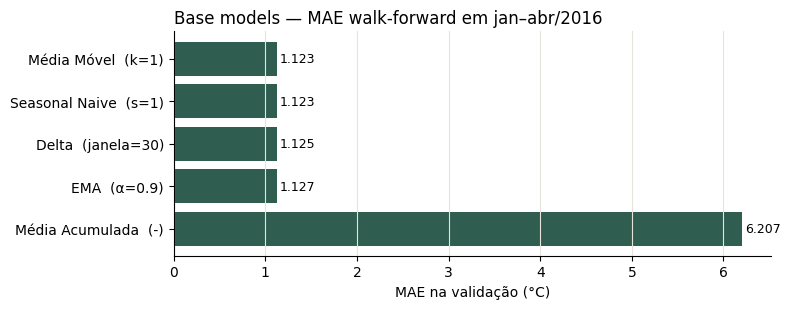

,Modelo,Parâmetro,MAE treino,MAE validação
0,Média Móvel,k=1,1.180,1.123
1,Seasonal Naive,s=1,1.180,1.123
2,Delta,janela=30,1.191,1.125
3,EMA,α=0.9,1.181,1.127
4,Média Acumulada,-,6.488,6.207


In [32]:
comparativo_base = (
    pd.DataFrame.from_dict(sumario, orient="index")
    .rename_axis("Modelo")
    .reset_index()
    .sort_values("MAE validação")
    .reset_index(drop=True)
)

# Configurações fixas que vão para o teste final
CONFIG_BASE = dict(zip(comparativo_base["Modelo"], comparativo_base["Parâmetro"]))

fig, ax = plt.subplots(figsize=(8, 3.2))
ordem = comparativo_base.iloc[::-1]
ax.barh(ordem["Modelo"] + "  (" + ordem["Parâmetro"] + ")", ordem["MAE validação"], color=COR)
for i, v in enumerate(ordem["MAE validação"]):
    ax.text(v + 0.03, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("MAE na validação (°C)")
ax.set_title("Base models — MAE walk-forward em jan–abr/2016")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("img/base_models.png", dpi=150)
plt.show()

comparativo_base.round(3)

**Interpretação dos base models:**
- Todos os modelos simples convergem para a **persistência** ("amanhã = hoje"): média móvel com k = 1 e seasonal naive com s = 1 são exatamente ela, e a EMA se aproxima à medida que α cresce (α = 0,9: 1,127 °C).
- O mesmo dia do ano anterior (s = 365) erra 3,3 °C: a variação entre anos é grande perto da variação de um dia para o outro.
- A média acumulada ignora o ciclo anual e erra mais de 6 °C.
- A régua para os quatro modelos é **1,123 °C**.

### SARIMA (univariado)

O SARIMA usa só a própria temperatura, sem externas e sem calendário. Os intervalos do grid saem da análise da base:

| Parâmetro | Evidência na base | Valores testados |
|---|---|---|
| **d** | ADF e KPSS discordam na série original; na 1ª diferença, os dois indicam estacionariedade | {0, 1} |
| **q** | ACF da 1ª diferença significativa nos lags 1 a 3 e próxima de zero depois | 0 a 3 |
| **p** | PACF da 1ª diferença significativa nos lags 1 a 3, decaindo depois | 0 a 3 |
| **m = 365** | Força da sazonalidade de 0,93 no STL e pico de +0,68 na ACF no lag 365: ciclo anual forte | D = 1 com P = Q = 0. A diferença anual *y<sub>t</sub> − y<sub>t−365</sub>* é aplicada antes do ajuste, e a previsão é reconstruída somando *y<sub>t−365</sub>*. P ou Q no lag 365 são inviáveis: no statsmodels, o vetor de estados passa de 365 dimensões. Num teste separado, um único ajuste `(1,0,0)(1,0,0,365)` limitado a 20 iterações passou de 9 minutos sem terminar, contra 1 a 4 segundos dos modelos sem esse termo. |
| **m = 7** | Sem motivo físico para um ciclo semanal na temperatura. A checagem abaixo confirma a ACF ≈ 0 nos múltiplos de 7. | (P, D, Q) ∈ {(1,0,0), (0,0,1), (1,0,1)}, só para confirmar a ausência |

**Procedimento:** triagem por AIC no treino inicial, comparando só modelos com a mesma diferenciação (mesmo `d` e com ou sem diferença anual). Passam para o walk-forward de validação as configurações com ΔAIC ≤ 2 em relação à melhor do grupo, e a escolha final é pelo MAE.

Não há transformação (log/Box-Cox): a dispersão não cresce com o nível da série (seção de limpeza).

In [33]:
import itertools
import warnings
from joblib import Parallel, delayed
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

INDEX_TREINO_INICIAL = dados.index[dados.index < ORIGENS_VALIDACAO[0]]

# Evidências calculadas só no treino inicial
y_tr = dados.loc[dados.index < ORIGENS_VALIDACAO[0], "y"]
d1 = y_tr.diff().dropna()
limite = 1.96 / np.sqrt(len(d1))
acf_d1, pacf_d1 = acf(d1, nlags=28), pacf(d1, nlags=8)

print(f"Limite de significância: ±{limite:.3f}")
print("ACF da 1ª diferença:  ", {k: round(acf_d1[k], 3) for k in range(1, 9)})
print("PACF da 1ª diferença: ", {k: round(pacf_d1[k], 3) for k in range(1, 9)})
print("ACF nos múltiplos de 7:", {k: round(acf_d1[k], 3) for k in (7, 14, 21, 28)})

z = (y_full - y_full.shift(365)).loc["2014-01-01":"2015-12-31"]
print(f"\nDiferença anual y[t] - y[t-365]: {len(z)} obs., desvio-padrão {z.std():.2f} °C "
      f"(1ª diferença: {d1.std():.2f} °C), ADF p = {adfuller(z)[1]:.1e}")

Limite de significância: ±0.060
ACF da 1ª diferença:   {1: np.float64(-0.158), 2: np.float64(-0.091), 3: np.float64(-0.114), 4: np.float64(0.013), 5: np.float64(-0.021), 6: np.float64(-0.02), 7: np.float64(-0.008), 8: np.float64(0.006)}
PACF da 1ª diferença:  {1: np.float64(-0.158), 2: np.float64(-0.119), 3: np.float64(-0.155), 4: np.float64(-0.05), 5: np.float64(-0.063), 6: np.float64(-0.062), 7: np.float64(-0.041), 8: np.float64(-0.026)}
ACF nos múltiplos de 7: {7: np.float64(-0.008), 14: np.float64(-0.015), 21: np.float64(-0.009), 28: np.float64(-0.006)}

Diferença anual y[t] - y[t-365]: 730 obs., desvio-padrão 3.01 °C (1ª diferença: 1.66 °C), ADF p = 7.9e-13


In [34]:
def serie_sarima(index, cfg):
    # Com a diferença anual, o modelo é ajustado em z[t] = y[t] - y[t-365]
    y = y_full.loc[index]
    return y - y_full.shift(365).loc[index] if cfg["anual"] else y


def ajustar_sarima(index, cfg):
    if cfg["anual"]:
        index = index[index >= y_full.index[0] + pd.Timedelta(days=365)]
    trend = "c" if cfg["order"][1] == 0 else "n"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(serie_sarima(index, cfg).values, order=cfg["order"],
                       seasonal_order=cfg["seasonal"], trend=trend).fit(disp=False, maxiter=200)


def nome_sarima(cfg):
    if cfg["anual"]:
        return f"SARIMA{cfg['order']}(0,1,0,365)"
    s = cfg["seasonal"]
    return f"SARIMA{cfg['order']}" + (f"({s[0]},{s[1]},{s[2]},{s[3]})" if s[3] else "")


SAZONAIS_7 = [(0, 0, 0, 0), (1, 0, 0, 7), (0, 0, 1, 7), (1, 0, 1, 7)]
grade_sarima = (
    [{"order": (p, d, q), "seasonal": s, "anual": False}
     for p, d, q, s in itertools.product(range(4), [0, 1], range(4), SAZONAIS_7)]
    + [{"order": (p, d, q), "seasonal": (0, 0, 0, 0), "anual": True}
       for p, d, q in itertools.product(range(4), [0, 1], range(4))]
)


def triagem_sarima(cfg):
    try:
        res = ajustar_sarima(INDEX_TREINO_INICIAL, cfg)
        return {**cfg, "aic": res.aic, "bic": res.bic}
    except Exception:
        return {**cfg, "aic": np.nan, "bic": np.nan}


inicio = time.perf_counter()
triagem_sar = pd.DataFrame(Parallel(n_jobs=-1)(delayed(triagem_sarima)(c) for c in grade_sarima))
print(f"{len(grade_sarima)} ajustes em {time.perf_counter() - inicio:.0f} s | "
      f"falhas: {triagem_sar['aic'].isna().sum()}")

# AIC só é comparável com a mesma diferenciação (d e diferença anual)
triagem_sar["d"] = triagem_sar["order"].apply(lambda o: o[1])
triagem_sar["modelo"] = triagem_sar.apply(nome_sarima, axis=1)
triagem_sar["grupo"] = np.where(triagem_sar["anual"], "D=1 (m=365)", "sem diferença anual")
validos_sar = triagem_sar.dropna(subset=["aic"]).copy()
validos_sar["delta_aic"] = validos_sar["aic"] - validos_sar.groupby(["grupo", "d"])["aic"].transform("min")
top_sarima = validos_sar[validos_sar["delta_aic"] <= 2].sort_values(["grupo", "d", "aic"])
print(f"Configurações com ΔAIC ≤ 2 (vão para o walk-forward): {len(top_sarima)}")
top_sarima[["grupo", "d", "modelo", "aic", "delta_aic", "bic"]].round(2)

160 ajustes em 26 s | falhas: 0
Configurações com ΔAIC ≤ 2 (vão para o walk-forward): 14


,grupo,d,modelo,aic,delta_aic,bic
139,D=1 (m=365),0,"SARIMA(1, 0, 3)(0,1,0,365)",3143.85,0.00,3171.41
145,D=1 (m=365),0,"SARIMA(2, 0, 1)(0,1,0,365)",3143.97,0.12,3166.94
136,D=1 (m=365),0,"SARIMA(1, 0, 0)(0,1,0,365)",3144.91,1.05,3158.68
147,D=1 (m=365),0,"SARIMA(2, 0, 3)(0,1,0,365)",3145.75,1.90,3177.90
150,D=1 (m=365),1,"SARIMA(2, 1, 2)(0,1,0,365)",3144.68,0.00,3167.64
141,D=1 (m=365),1,"SARIMA(1, 1, 1)(0,1,0,365)",3145.62,0.94,3159.40
44,sem diferença anual,0,"SARIMA(1, 0, 3)",4028.70,0.00,4058.52
68,sem diferença anual,0,"SARIMA(2, 0, 1)",4030.03,1.33,4054.88
45,sem diferença anual,0,"SARIMA(1, 0, 3)(1,0,0,7)",4030.30,1.60,4065.10
46,sem diferença anual,0,"SARIMA(1, 0, 3)(0,0,1,7)",4030.30,1.61,4065.10


In [35]:
# Efeito do termo sazonal semanal: melhor AIC com e sem m = 7, para cada d
sem_anual = triagem_sar[~triagem_sar["anual"]].copy()
sem_anual["m=7"] = sem_anual["seasonal"].apply(lambda s: s[3] == 7)
sem_anual.pivot_table(index="d", columns="m=7", values="aic", aggfunc="min").round(1)

m=7,False,True
d,,
0,4028.7,4030.3
1,4018.8,4020.7


In [36]:
# Etapa 2: MAE walk-forward na validação para as configurações com ΔAIC ≤ 2 em cada grupo
def prever_sarima(cfg):
    def prever_bloco(hist, bloco):
        res = ajustar_sarima(hist.index, cfg)
        estendido = res.append(serie_sarima(bloco, cfg).values, refit=False)
        pred = estendido.fittedvalues[-len(bloco):]
        return pred + y_full.shift(365).loc[bloco].values if cfg["anual"] else pred
    return prever_bloco


def validar_sarima(cfg):
    r = walk_forward(prever_sarima(cfg), ORIGENS_VALIDACAO)
    return {"modelo": nome_sarima(cfg), "cfg": cfg, "MAE validação": r["mae"], "tempo (s)": r["tempo_s"]}


candidatos_sarima = [{k: row[k] for k in ["order", "seasonal", "anual"]} for _, row in top_sarima.iterrows()]
busca_sarima = (pd.DataFrame(Parallel(n_jobs=-1)(delayed(validar_sarima)(c) for c in candidatos_sarima))
                .sort_values("MAE validação").reset_index(drop=True))

MELHOR_SARIMA = busca_sarima.loc[0, "cfg"]
sumario["SARIMA"] = {"Parâmetro": nome_sarima(MELHOR_SARIMA).replace("SARIMA", ""),
                     "MAE treino": np.nan, "MAE validação": busca_sarima.loc[0, "MAE validação"]}
print("SARIMA escolhido:", nome_sarima(MELHOR_SARIMA))
print(f"Referência — persistência: {persistencia_val['mae']:.3f} °C")
busca_sarima[["modelo", "MAE validação", "tempo (s)"]].round(3)

SARIMA escolhido: SARIMA(2, 0, 1)
Referência — persistência: 1.123 °C


,modelo,MAE validação,tempo (s)
0,"SARIMA(2, 0, 1)",1.152,15.871
1,"SARIMA(2, 0, 3)",1.156,20.581
2,"SARIMA(1, 0, 3)",1.157,12.439
3,"SARIMA(1, 0, 3)(0,0,1,7)",1.158,24.584
4,"SARIMA(3, 1, 3)",1.166,26.054
5,"SARIMA(3, 1, 3)(1,0,0,7)",1.167,33.012
6,"SARIMA(3, 1, 3)(0,0,1,7)",1.167,36.092
7,"SARIMA(1, 1, 1)(0,1,0,365)",1.473,6.540
8,"SARIMA(1, 0, 3)(0,1,0,365)",1.490,5.779
9,"SARIMA(2, 0, 3)(0,1,0,365)",1.491,9.289


**Interpretação do SARIMA:**
- **Sazonal semanal descartada:** o termo m = 7 nunca melhorou o AIC (4.028,7 sem e 4.030,3 com, para d = 0). Isso confirma a ACF ≈ 0 nos múltiplos de 7.
- **Diferença anual pior na validação:** com ela, os modelos erram de 1,47 a 1,50 °C, contra 1,15 a 1,17 °C sem ela. A série diferenciada por ano é estacionária, mas tem o dobro da dispersão (dp 3,0 °C contra 1,7 °C), porque cada dia do ano carrega o ruído de dois anos diferentes.
- **SARIMA(1,0,3)(1,0,0,7) com MAE de 3,9 °C:** o ajuste ficou instável no walk-forward. É mais um sinal de que o termo semanal não tem suporte nos dados.
- **Escolhido: SARIMA(2,0,1)** com constante, MAE de 1,152 °C. Sem externas e sem tratamento suave do ciclo anual, ele não supera a persistência (1,123 °C).

### SARIMAX

**Como a sazonalidade anual entra no modelo.** Como visto no SARIMA, termos sazonais com `m = 365` são inviáveis, e a diferença anual gasta um ano de dados e dobra a dispersão da série. No SARIMAX, o ciclo anual entra como **termos de Fourier** (seno e cosseno do dia do ano, harmônicos 1 a *K*) nas exógenas. É a regressão harmônica dinâmica, a alternativa usual para sazonalidades longas.

**Espaço de busca e justificativa de cada intervalo:**

| Elemento | Valores | Justificativa |
|---|---|---|
| p, q | 0 a 3 | ACF e PACF da 1ª diferença significativas nos lags 1 a 3 (mesma evidência do SARIMA) |
| d | 0 (com constante), 1 (sem constante) | ADF e KPSS discordam na série original e concordam na 1ª diferença. Com Fourier, a sazonalidade passa a ser determinística, e d = 0 volta a ser plausível. |
| Fourier anual (*K* harmônicos) | 1, 2, 3 | Ver a célula abaixo: K = 1 não captura a assimetria do ciclo (patamar da monção, queda rápida no outono), K = 2 já explica ~99% da componente sazonal suavizada, e K = 3 confirma o platô. |
| Externas defasadas | nenhuma; ontem (lag 1); ontem + anteontem (lags 1–2); semana (lags 1–7) | Os conjuntos testados na seção de features, com h = 1. Correlação com a temperatura: umidade −0,57, vento +0,31. |
| Sazonal (P, D, Q, m) | m = 7 com (P, Q) ∈ {0, 1}² e D = 0, em todas as combinações | A base não indica ciclo semanal (ACF ≈ 0 nos múltiplos de 7). Ele fica no grid completo para comprovar a ausência. D = 0 porque não há evidência que justifique diferenciar por semana. m = 365 é inviável (ver SARIMA). |

**Procedimento em duas etapas:**
1. **Triagem por AIC.** Cada combinação é ajustada uma vez no treino inicial (31/01/2013 a 31/12/2015). O AIC só é comparável entre modelos com o mesmo `d`, porque a diferenciação muda a amostra da verossimilhança.
2. **Decisão por MAE.** Passam para o walk-forward de validação todas as configurações com **ΔAIC ≤ 2** em relação à melhor do mesmo `d`. Modelos a menos de 2 pontos de AIC do melhor são considerados praticamente indistinguíveis pelo critério (Burnham & Anderson). A de menor MAE é a escolhida.

In [37]:
EXOG_SARIMAX = {"nenhuma": [], **{k: v for k, v in CONJUNTOS_EXTERNAS.items() if v}}


def fourier(index, K):
    dia = index.dayofyear.values
    return np.column_stack([f(2 * np.pi * k * dia / 365.25)
                            for k in range(1, K + 1) for f in (np.sin, np.cos)])


def matriz_exog(index, cfg):
    # Fourier é calendário (conhecido antecipadamente); as externas já estão defasadas
    partes = [fourier(index, cfg["K"])]
    if EXOG_SARIMAX[cfg["exog"]]:
        partes.append(dados.loc[index, EXOG_SARIMAX[cfg["exog"]]].values)
    return np.column_stack(partes)


def ajustar_sarimax(index, cfg):
    trend = "c" if cfg["order"][1] == 0 else "n"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        modelo = SARIMAX(dados.loc[index, "y"].values, exog=matriz_exog(index, cfg),
                         order=cfg["order"], seasonal_order=cfg["seasonal"], trend=trend)
        return modelo.fit(disp=False, maxiter=200)


def r2_fourier(K):
    # Quanto da componente sazonal do STL (treino inicial) K harmônicos explicam
    s = STL(dados.loc[INDEX_TREINO_INICIAL, "y"], period=365, robust=True, seasonal_deg=0).fit().seasonal
    s = s.rolling(30, center=True, min_periods=1).mean()
    X = np.column_stack([np.ones(len(s)), fourier(s.index, K)])
    beta = np.linalg.lstsq(X, s.values, rcond=None)[0]
    return 1 - np.var(s.values - X @ beta) / np.var(s.values)


print("R² da componente sazonal suavizada explicada por K harmônicos:")
print({K: round(r2_fourier(K), 3) for K in range(1, 7)})


def nome_cfg(cfg):
    s = cfg["seasonal"]
    sazonal = f"({s[0]},{s[1]},{s[2]},{s[3]})" if s[3] else ""
    return f"SARIMAX{cfg['order']}{sazonal} K={cfg['K']} | {cfg['exog']}"

R² da componente sazonal suavizada explicada por K harmônicos:
{1: np.float64(0.916), 2: np.float64(0.989), 3: np.float64(0.996), 4: np.float64(0.998), 5: np.float64(0.998), 6: np.float64(0.999)}


In [38]:
# Etapa 1: triagem por AIC no treino inicial

SAZONAIS_SARIMAX = [(0, 0, 0, 0), (1, 0, 0, 7), (0, 0, 1, 7), (1, 0, 1, 7)]
grade = [
    {"order": (p, d, q), "seasonal": s, "K": K, "exog": exog}
    for p, d, q, s, K, exog in itertools.product(range(4), [0, 1], range(4), SAZONAIS_SARIMAX,
                                                  [1, 2, 3], EXOG_SARIMAX)
]


def triagem(cfg):
    try:
        res = ajustar_sarimax(INDEX_TREINO_INICIAL, cfg)
        return {**cfg, "aic": res.aic, "bic": res.bic,
                "convergiu": res.mle_retvals.get("converged", True)}
    except Exception as e:
        return {**cfg, "aic": np.nan, "bic": np.nan, "convergiu": False}


inicio = time.perf_counter()
triagem_sarimax = pd.DataFrame(Parallel(n_jobs=-1)(delayed(triagem)(cfg) for cfg in grade))
print(f"{len(grade)} ajustes em {time.perf_counter() - inicio:.0f} s | "
      f"falhas: {triagem_sarimax['aic'].isna().sum()} | "
      f"sem convergência: {(~triagem_sarimax['convergiu']).sum()}")

triagem_sarimax["d"] = triagem_sarimax["order"].apply(lambda o: o[1])
validos = triagem_sarimax.dropna(subset=["aic"]).copy()
validos["delta_aic"] = validos["aic"] - validos.groupby("d")["aic"].transform("min")
top_aic = validos[validos["delta_aic"] <= 2].sort_values(["d", "aic"])
print(f"Configurações com ΔAIC ≤ 2 (vão para o walk-forward): {len(top_aic)}")
top_aic.assign(modelo=top_aic.apply(nome_cfg, axis=1))[["modelo", "d", "aic", "delta_aic", "bic", "convergiu"]].round(2)

1536 ajustes em 1845 s | falhas: 0 | sem convergência: 386
Configurações com ΔAIC ≤ 2 (vão para o walk-forward): 12


,modelo,d,aic,delta_aic,bic,convergiu
394,"SARIMAX(1, 0, 0) K=3 | ontem + anteontem (lags...",0,3921.28,0.00,3985.90,True
393,"SARIMAX(1, 0, 0) K=3 | ontem (lag 1)",0,3921.70,0.42,3976.38,True
442,"SARIMAX(1, 0, 1) K=3 | ontem + anteontem (lags...",0,3923.13,1.86,3992.72,True
778,"SARIMAX(2, 0, 0) K=3 | ontem + anteontem (lags...",0,3923.14,1.86,3992.73,True
418,"SARIMAX(1, 0, 0)(0,0,1,7) K=3 | ontem + anteon...",0,3923.27,1.99,3992.86,True
406,"SARIMAX(1, 0, 0)(1,0,0,7) K=3 | ontem + anteon...",0,3923.28,2.00,3992.87,True
1497,"SARIMAX(3, 1, 3) K=3 | ontem (lag 1)",1,3923.13,0.00,3997.68,False
634,"SARIMAX(1, 1, 1) K=3 | ontem + anteontem (lags...",1,3923.34,0.20,3987.94,True
633,"SARIMAX(1, 1, 1) K=3 | ontem (lag 1)",1,3923.65,0.52,3978.32,True
1498,"SARIMAX(3, 1, 3) K=3 | ontem + anteontem (lags...",1,3924.99,1.85,4009.47,False


In [39]:
# Panorama: melhor AIC por número de harmônicos e por conjunto de externas (dentro de cada d)
validos["m=7"] = validos["seasonal"].apply(lambda s: s[3] == 7)
print("Melhor AIC com e sem sazonal semanal:")
print(validos.pivot_table(index="m=7", columns="d", values="aic", aggfunc="min").round(1).to_string())
print("\nMelhor AIC por K:")
print(validos.pivot_table(index="K", columns="d", values="aic", aggfunc="min").round(1).to_string())
print("\nMelhor AIC por conjunto de externas:")
print(validos.pivot_table(index="exog", columns="d", values="aic", aggfunc="min").round(1).to_string())

Melhor AIC com e sem sazonal semanal:
d           0       1
m=7                  
False  3921.3  3923.1
True   3923.3  3925.0

Melhor AIC por K:
d       0       1
K                
1  3979.3  3980.0
2  3930.5  3931.2
3  3921.3  3923.1

Melhor AIC por conjunto de externas:
d                                  0       1
exog                                        
nenhuma                       3924.9  3926.4
ontem (lag 1)                 3921.7  3923.1
ontem + anteontem (lags 1-2)  3921.3  3923.3
semana (lags 1-7)             3932.3  3934.3


In [40]:
# Etapa 2: MAE walk-forward na validação
def prever_sarimax(cfg):
    def prever_bloco(hist, bloco):
        res = ajustar_sarimax(hist.index, cfg)
        # append sem reajuste: os parâmetros ficam fixos e o filtro de Kalman incorpora
        # os valores reais do bloco; o fittedvalue do dia t usa só y até t-1
        estendido = res.append(dados.loc[bloco, "y"].values, exog=matriz_exog(bloco, cfg),
                               refit=False)
        return estendido.fittedvalues[-len(bloco):]
    return prever_bloco


candidatos = [{k: row[k] for k in ["order", "seasonal", "K", "exog"]} for _, row in top_aic.iterrows()]


def validar(cfg):
    try:
        r = walk_forward(prever_sarimax(cfg), ORIGENS_VALIDACAO)
        return {"modelo": nome_cfg(cfg), "cfg": cfg, "MAE validação": r["mae"], "tempo (s)": r["tempo_s"]}
    except Exception as e:
        return {"modelo": nome_cfg(cfg), "cfg": cfg, "MAE validação": np.nan, "tempo (s)": np.nan}


inicio = time.perf_counter()
busca_sarimax = (pd.DataFrame(Parallel(n_jobs=-1)(delayed(validar)(c) for c in candidatos))
                 .sort_values("MAE validação").reset_index(drop=True))
print(f"{len(candidatos)} configurações validadas em {time.perf_counter() - inicio:.0f} s")
print(f"Referência — persistência: {persistencia_val['mae']:.3f} °C")
busca_sarimax[["modelo", "MAE validação", "tempo (s)"]].round(3)

12 configurações validadas em 289 s
Referência — persistência: 1.123 °C


,modelo,MAE validação,tempo (s)
0,"SARIMAX(3, 1, 3) K=3 | ontem (lag 1)",1.192,200.480
1,"SARIMAX(1, 1, 1) K=3 | ontem (lag 1)",1.192,65.661
2,"SARIMAX(1, 1, 1) K=3 | ontem + anteontem (lags...",1.199,97.351
3,"SARIMAX(3, 1, 3)(1,0,0,7) K=3 | ontem (lag 1)",1.205,288.482
4,"SARIMAX(3, 1, 3) K=3 | ontem + anteontem (lags...",1.206,222.136
5,"SARIMAX(3, 1, 3)(0,0,1,7) K=3 | ontem (lag 1)",1.211,288.975
6,"SARIMAX(1, 0, 0) K=3 | ontem (lag 1)",1.283,75.894
7,"SARIMAX(1, 0, 0)(1,0,0,7) K=3 | ontem + anteon...",1.286,207.047
8,"SARIMAX(1, 0, 0)(0,0,1,7) K=3 | ontem + anteon...",1.287,242.206
9,"SARIMAX(1, 0, 0) K=3 | ontem + anteontem (lags...",1.287,105.855


In [41]:
MELHOR_SARIMAX = busca_sarimax.loc[0, "cfg"]
print("SARIMAX escolhido:", nome_cfg(MELHOR_SARIMAX))
print(f"MAE validação: {busca_sarimax.loc[0, 'MAE validação']:.3f} °C "
      f"(persistência: {persistencia_val['mae']:.3f} °C)")

sumario["SARIMAX"] = {"Parâmetro": nome_cfg(MELHOR_SARIMAX).replace("SARIMAX", ""),
                      "MAE treino": np.nan,
                      "MAE validação": busca_sarimax.loc[0, "MAE validação"]}

# Coeficientes do modelo escolhido, ajustado no treino inicial
res_sarimax = ajustar_sarimax(INDEX_TREINO_INICIAL, MELHOR_SARIMAX)
nomes = ([f"{f}{k}" for k in range(1, MELHOR_SARIMAX["K"] + 1) for f in ("sin", "cos")]
         + EXOG_SARIMAX[MELHOR_SARIMAX["exog"]])
coef = pd.DataFrame({"coef": res_sarimax.params, "p-valor": res_sarimax.pvalues}, index=res_sarimax.param_names)
coef.index = [nomes[int(i[1:]) - 1] if i.startswith("x") and i[1:].isdigit() else i for i in coef.index]
coef.round(4)

SARIMAX escolhido: SARIMAX(3, 1, 3) K=3 | ontem (lag 1)
MAE validação: 1.192 °C (persistência: 1.123 °C)


,coef,p-valor
sin1,-0.9230,0.0002
cos1,-9.5575,0.0000
sin2,-1.5720,0.0000
cos2,-2.2972,0.0000
sin3,0.7835,0.0004
cos3,0.0507,0.8287
humidity_lag1,0.0041,0.5283
wind_speed_lag1,-0.0253,0.0322
ar.L1,-0.9045,0.0000
ar.L2,0.1274,0.0017


#### Validação do SARIMAX

Três checagens para confirmar que o SARIMAX escolhido se sustenta:
1. **Ablação:** a mesma configuração sem as externas (só Fourier) e sem nada (ARIMA puro). Isso mostra quanto vem do ciclo anual e quanto vem da umidade e do vento.
2. **Comparação com o SARIMA e com a persistência,** no mesmo walk-forward.
3. **Resíduos do ajuste no treino inicial:** Ljung-Box (o modelo deixou autocorrelação para trás?) e significância dos coeficientes das externas.

In [42]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ablacao = [
    ("SARIMAX escolhido", MELHOR_SARIMAX),
    ("mesma ordem, sem externas (só Fourier)", {**MELHOR_SARIMAX, "exog": "nenhuma"}),
]


def validar_ablacao(rotulo, cfg):
    return {"configuração": rotulo, "modelo": nome_cfg(cfg),
            "MAE validação": walk_forward(prever_sarimax(cfg), ORIGENS_VALIDACAO)["mae"]}


linhas = Parallel(n_jobs=-1)(delayed(validar_ablacao)(r, c) for r, c in ablacao)
linhas.append({"configuração": "mesma ordem, sem Fourier e sem externas",
               "modelo": nome_sarima({"order": MELHOR_SARIMAX["order"], "seasonal": (0, 0, 0, 0), "anual": False}),
               "MAE validação": walk_forward(prever_sarima({"order": MELHOR_SARIMAX["order"],
                                                            "seasonal": (0, 0, 0, 0), "anual": False}),
                                             ORIGENS_VALIDACAO)["mae"]})
linhas.append({"configuração": "melhor SARIMA", "modelo": nome_sarima(MELHOR_SARIMA),
               "MAE validação": busca_sarima.loc[0, "MAE validação"]})
linhas.append({"configuração": "persistência", "modelo": "y[t-1]", "MAE validação": persistencia_val["mae"]})
pd.DataFrame(linhas).sort_values("MAE validação").round(3)

,configuração,modelo,MAE validação
4,persistência,y[t-1],1.123
3,melhor SARIMA,"SARIMA(2, 0, 1)",1.152
2,"mesma ordem, sem Fourier e sem externas","SARIMA(3, 1, 3)",1.166
0,SARIMAX escolhido,"SARIMAX(3, 1, 3) K=3 | ontem (lag 1)",1.192
1,"mesma ordem, sem externas (só Fourier)","SARIMAX(3, 1, 3) K=3 | nenhuma",1.208


Ljung-Box nos resíduos do treino:
    lb_stat  lb_pvalue
7    3.1593     0.8699
14  12.8698     0.5368
30  27.7327     0.5846


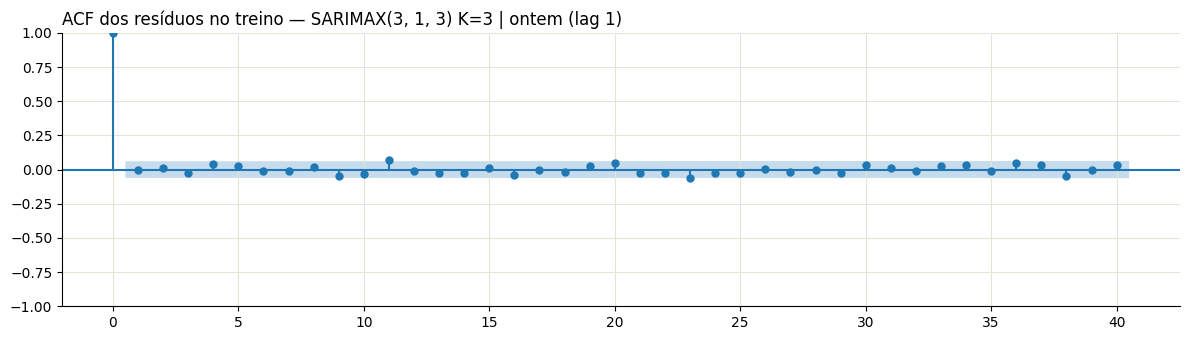

Coeficientes das externas:
                   coef  p-valor
humidity_lag1    0.0041   0.5283
wind_speed_lag1 -0.0253   0.0322


In [43]:
# Resíduos do SARIMAX escolhido no treino inicial (descarta o início, afetado pela inicialização)
residuos_sarimax = res_sarimax.resid[30:]
lb = acorr_ljungbox(residuos_sarimax, lags=[7, 14, 30], return_df=True)
print("Ljung-Box nos resíduos do treino:")
print(lb.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 3.5))
plot_acf(residuos_sarimax, lags=40, ax=ax)
ax.set_title(f"ACF dos resíduos no treino — {nome_cfg(MELHOR_SARIMAX)}")
plt.tight_layout()
plt.show()

externas_sel = EXOG_SARIMAX[MELHOR_SARIMAX["exog"]]
print("Coeficientes das externas:")
print(coef.loc[coef.index.isin(externas_sel)].round(4).to_string())

**Interpretação do SARIMAX:**
- **K harmônicos:** o melhor AIC melhora muito de K = 1 para K = 2 (3.979 → 3.930) e pouco de 2 para 3 (→ 3.921). Isso acompanha o R² da componente sazonal suavizada (0,916 → 0,989 → 0,996).
- **Externas:**
  - Melhor AIC: ontem (3.921,7) e ontem + anteontem (3.921,3) empatam.
  - A semana inteira fica pior (3.932,3), e sem externas também (3.924,9).
  - O termo semanal m = 7 de novo não melhorou o AIC.
- **d = 0 × d = 1 no walk-forward:** os candidatos com d = 0 erraram mais (1,28 a 1,29 °C) do que os com d = 1 (1,19 a 1,21 °C). O AIC não compara modelos com d diferente, e é por isso que a decisão final é pelo MAE.
- **Escolhido: SARIMAX(3,1,3), Fourier K = 3, umidade e vento de ontem,** MAE de validação de 1,192 °C.
- **Validação do modelo escolhido:**
  - Ablação: sem as externas, o MAE sobe para 1,208 °C. A contribuição de umidade e vento é real, mas pequena (0,016 °C).
  - Coeficientes: só o vento de ontem é significativo (−0,025, p = 0,03). A umidade não é (p = 0,53).
  - Resíduos do treino: o Ljung-Box não indica autocorrelação (p = 0,87, 0,54 e 0,58 nos lags 7, 14 e 30).
  - Na validação, o SARIMAX fica acima da persistência e do melhor SARIMA.
- **Ressalva de convergência:** 386 das 1.536 combinações não convergiram na triagem, inclusive a ordem escolhida. Os coeficientes MA do ajuste no treino inicial têm p-valor ≈ 0,99 (ma.L3 = −0,999, raiz MA perto do círculo unitário). No ajuste final, com todo o histórico até 2016, eles ficam bem determinados (seção de importância).

### Holt-Winters

Referência univariada: usa só a temperatura, sem externas. O grid é pequeno o suficiente para passar inteiro pelo walk-forward de validação.

| Parâmetro | Valores testados | Justificativa |
|---|---|---|
| Tendência | nenhuma, aditiva, multiplicativa; amortecida ou não | A força da tendência é de 0,19 (fraca), então espera-se "nenhuma" ou "amortecida". As demais ficam para confirmar. |
| Sazonalidade | nenhuma, aditiva, multiplicativa | A amplitude do ciclo é estável entre os anos e a série não precisou de Box-Cox, então espera-se aditiva. A multiplicativa fica para confirmar. |
| Período sazonal | 365, 7 | Ciclo anual forte (F_S = 0,93). O semanal, sem evidência na ACF, fica para confirmar a ausência. |
| Inicialização da sazonalidade (m = 365) | heurística; perfil de Fourier | Ver abaixo |
| γ (suavização da sazonalidade, m = 365) | estimado; 0; 0,01; 0,05; 0,1 | Ver abaixo |
| α, β, φ | estimados por máxima verossimilhança em cada reajuste | Os valores do modelo escolhido aparecem abaixo |

**Por que a inicialização importa com m = 365.** O modelo mantém um índice sazonal para cada dia do ano, e cada índice é visto só 3 vezes no treino.
- **Inicialização heurística:** calcula os índices iniciais a partir dos valores reais dos dois primeiros anos, então eles nascem com o ruído diário embutido (o resíduo do STL tem dp ≈ 1,9 °C). Com γ estimado alto, continuam absorvendo ruído.
- **Perfil de Fourier:** em cada reajuste, os índices iniciais são tirados de um perfil sazonal suave, uma curva de Fourier com K = 2 (que explica ~99% da componente sazonal) ajustada só no histórico daquele reajuste. O modelo continua univariado, porque o perfil sai da própria temperatura passada.
- **γ pequeno:** limita quanto cada índice é puxado pelo valor do dia, mantendo o perfil suave. γ = 0 deixa o perfil fixo.

Para m = 7, e quando não há sazonalidade, usa-se a inicialização heurística (o perfil de Fourier é anual).

**Previsão dentro do bloco.** A cada 7 dias os parâmetros de suavização são reestimados. Nos dias intermediários o modelo é reaplicado à série com os parâmetros fixos, e o valor ajustado do dia *t* é a previsão 1 passo à frente feita com dados até *t−1*.

In [44]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

PARAMS_SUAVIZACAO = ["smoothing_level", "smoothing_trend", "smoothing_seasonal", "damping_trend"]


def estados_iniciais(hist, cfg):
    # Perfil de Fourier (K = 2) ajustado só no histórico; índices do primeiro ciclo da série
    if cfg["init"] != "fourier":
        return None
    X = np.column_stack([np.ones(len(hist)), fourier(hist.index, 2)])
    beta = np.linalg.lstsq(X, hist.values, rcond=None)[0]
    perfil = fourier(hist.index[:cfg["m"]], 2) @ beta[1:]
    nivel = beta[0]
    sazonal = perfil if cfg["seasonal"] == "add" else (nivel + perfil) / nivel
    return {"initial_level": nivel, "initial_seasonal": sazonal,
            **({"initial_trend": 0.0 if cfg["trend"] == "add" else 1.0} if cfg["trend"] else {})}


def ajustar_hw(y, cfg, params=None, iniciais=None):
    inicializacao = {"initialization_method": "known", **iniciais} if iniciais else         {"initialization_method": "heuristic"}
    modelo = ExponentialSmoothing(
        y, trend=cfg["trend"], damped_trend=cfg["damped"], seasonal=cfg["seasonal"],
        seasonal_periods=cfg["m"] if cfg["seasonal"] else None, **inicializacao,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if params:
            return modelo.fit(**params, optimized=False)
        fixos = {} if cfg["gamma"] is None else {"smoothing_seasonal": cfg["gamma"]}
        return modelo.fit(**fixos)


def prever_hw(cfg):
    def prever_bloco(hist, bloco):
        y_hist = hist["y"].asfreq("D")
        iniciais = estados_iniciais(y_hist, cfg)
        res = ajustar_hw(y_hist, cfg, iniciais=iniciais)
        params = {k: v for k, v in res.params.items() if k in PARAMS_SUAVIZACAO and pd.notna(v)}
        # Mesmo início da série e mesmos estados iniciais: só os dados novos entram no filtro
        fixo = ajustar_hw(dados.loc[:bloco[-1], "y"].asfreq("D"), cfg, params, iniciais)
        return fixo.fittedvalues.loc[bloco].values
    return prever_bloco


def nome_hw(cfg):
    tendencia = "nenhuma" if cfg["trend"] is None else cfg["trend"] + (" amortecida" if cfg["damped"] else "")
    sazonal = "nenhuma" if cfg["seasonal"] is None else f"{cfg['seasonal']} (m={cfg['m']})"
    extra = ""
    if cfg["seasonal"]:
        gamma = "estimado" if cfg["gamma"] is None else cfg["gamma"]
        extra = f" | init {cfg['init']} | γ {gamma}"
    return f"tendência {tendencia} | sazonal {sazonal}{extra}"


TENDENCIAS = [(None, False), ("add", False), ("add", True), ("mul", False), ("mul", True)]
grade_hw = []
for t, dp in TENDENCIAS:
    base_cfg = {"trend": t, "damped": dp}
    grade_hw.append({**base_cfg, "seasonal": None, "m": None, "init": "heurística", "gamma": None})
    for s_tipo in ["add", "mul"]:
        grade_hw.append({**base_cfg, "seasonal": s_tipo, "m": 7, "init": "heurística", "gamma": None})
        grade_hw.append({**base_cfg, "seasonal": s_tipo, "m": 365, "init": "heurística", "gamma": None})
        for g in [None, 0.0, 0.01, 0.05, 0.1]:
            grade_hw.append({**base_cfg, "seasonal": s_tipo, "m": 365, "init": "fourier", "gamma": g})


def validar_hw(cfg):
    try:
        r = walk_forward(prever_hw(cfg), ORIGENS_VALIDACAO)
        return {"modelo": nome_hw(cfg), "cfg": cfg, "MAE validação": r["mae"], "tempo (s)": r["tempo_s"]}
    except Exception as e:
        return {"modelo": nome_hw(cfg), "cfg": cfg, "MAE validação": np.nan, "tempo (s)": np.nan,
                "erro": type(e).__name__}


inicio = time.perf_counter()
busca_hw = (pd.DataFrame(Parallel(n_jobs=-1)(delayed(validar_hw)(c) for c in grade_hw))
            .sort_values("MAE validação").reset_index(drop=True))
print(f"{len(grade_hw)} configurações em {time.perf_counter() - inicio:.0f} s | "
      f"falhas: {busca_hw['MAE validação'].isna().sum()}")
print(f"Referência — persistência: {persistencia_val['mae']:.3f} °C")
busca_hw[["modelo", "MAE validação", "tempo (s)"]].round(3)

75 configurações em 39 s | falhas: 0
Referência — persistência: 1.123 °C


,modelo,MAE validação,tempo (s)
0,tendência mul amortecida | sazonal add (m=365)...,1.116,3.181
1,tendência nenhuma | sazonal add (m=365) | init...,1.118,0.328
2,tendência mul | sazonal add (m=365) | init fou...,1.118,2.157
3,tendência add | sazonal add (m=365) | init fou...,1.118,2.013
4,tendência add amortecida | sazonal add (m=365)...,1.118,1.481
...,...,...,...
70,tendência add amortecida | sazonal mul (m=365)...,1.435,5.333
71,tendência nenhuma | sazonal mul (m=365) | init...,1.435,0.722
72,tendência mul amortecida | sazonal mul (m=365)...,1.435,20.450
73,tendência add | sazonal mul (m=365) | init heu...,1.435,7.616


In [45]:
MELHOR_HW = busca_hw.loc[0, "cfg"]
sumario["Holt-Winters"] = {"Parâmetro": nome_hw(MELHOR_HW), "MAE treino": np.nan,
                           "MAE validação": busca_hw.loc[0, "MAE validação"]}

# Parâmetros de suavização do modelo escolhido, estimados no treino inicial
y_ini = dados.loc[INDEX_TREINO_INICIAL, "y"].asfreq("D")
res_hw = ajustar_hw(y_ini, MELHOR_HW, iniciais=estados_iniciais(y_ini, MELHOR_HW))
print("Holt-Winters escolhido:", nome_hw(MELHOR_HW))
print({k: round(float(res_hw.params[k]), 4) for k in PARAMS_SUAVIZACAO if pd.notna(res_hw.params.get(k))})

Holt-Winters escolhido: tendência mul amortecida | sazonal add (m=365) | init fourier | γ 0.05
{'smoothing_level': 0.7663, 'smoothing_trend': 0.0, 'smoothing_seasonal': 0.05, 'damping_trend': 0.995}


**Interpretação do Holt-Winters:**
- **A inicialização decide o resultado:**
  - Com a heurística, a sazonalidade anual *piora* o modelo: 1,358 °C na aditiva e 1,435 °C na multiplicativa. Cada um dos 365 índices é visto só 3 vezes no treino e nasce com o ruído diário embutido.
  - Com o perfil de Fourier, o MAE cai para 1,116 a 1,118 °C.
- **Sazonalidade:** a aditiva ganha da multiplicativa, coerente com a amplitude estável do ciclo. O período 7 fica entre 1,20 e 1,23 °C, de novo sem ciclo semanal.
- **Tendência:** as cinco opções empatam (1,116 a 1,118 °C). A escolhida (multiplicativa amortecida) tem β = 0 e φ = 0,995, ou seja, é praticamente constante, como a força de tendência de 0,19 indicava.
- **Parâmetros:** α = 0,77 (o nível segue de perto os últimos dias) e γ = 0,05 (perfil sazonal estável).
- **Escolhido:** MAE de 1,116 °C, o único modelo estatístico abaixo da persistência na validação.

### Random Forest e XGBoost

Os dois usam **exatamente a mesma tabela de features**, a escolhida na seção de features (lags e janelas do alvo, calendário cíclico e umidade e vento de ontem e anteontem), e o mesmo walk-forward.

**Modo do alvo como hiperparâmetro:** *nível* (a árvore prevê *y<sub>t</sub>*) ou *diferença* (prevê *y<sub>t</sub> − y<sub>t−1</sub>* e soma a temperatura de ontem). Na seção de features, o modo diferença ganhou com hiperparâmetros padrão. Aqui ele volta ao grid, porque com outros hiperparâmetros o resultado pode mudar.

**Grid em duas etapas.** O grid completo dos dois modelos passaria de 1.000 configurações, cada uma com 18 reajustes. Por isso os parâmetros cujo efeito é previsível ficam para uma segunda etapa, aplicada sobre a melhor configuração da primeira:
- no Random Forest, `n_estimators`: mais árvores só reduzem a variância da média e não mudam o viés, então o ganho satura;
- no XGBoost, o ajuste fino de `reg_lambda`: a etapa 1 testa 1 e 10, e a etapa 2 refina em torno do melhor valor (÷10, ÷3, ×3, ×10).

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor

FEATURE_COLS = FEATURE_SETS["ontem + anteontem (lags 1-2)"]
MODOS = ["nível", "diferença"]


def alvo(linhas, modo):
    return linhas["y"] - linhas["temp_lag1"] if modo == "diferença" else linhas["y"]


def prever_arvore(fabrica, params, modo):
    def prever_bloco(hist, bloco):
        modelo = fabrica(params).fit(hist[FEATURE_COLS], alvo(hist, modo))
        p = modelo.predict(dados.loc[bloco, FEATURE_COLS])
        return p + dados.loc[bloco, "temp_lag1"].values if modo == "diferença" else p
    return prever_bloco


def busca_arvore(fabrica, grade, modos=MODOS):
    def avaliar(params, modo):
        r = walk_forward(prever_arvore(fabrica, params, modo), ORIGENS_VALIDACAO)
        return {"params": params, "modo": modo, "MAE validação": r["mae"], "tempo (s)": r["tempo_s"]}

    combinacoes = [(p, m) for p in ParameterGrid(grade) for m in modos]
    inicio = time.perf_counter()
    linhas = Parallel(n_jobs=-1)(delayed(avaliar)(p, m) for p, m in combinacoes)
    print(f"{len(combinacoes)} configurações em {time.perf_counter() - inicio:.0f} s")
    busca = pd.DataFrame(linhas).sort_values("MAE validação").reset_index(drop=True)
    return pd.concat([pd.json_normalize(busca["params"]), busca.drop(columns="params")], axis=1)


INTEIROS = {"max_depth", "min_samples_split", "min_samples_leaf", "n_estimators"}


def como_param(k, v):
    # json_normalize transforma None em NaN e inteiros em float
    if isinstance(v, str) or v is None:
        return v
    if pd.isna(v):
        return None
    return int(v) if k in INTEIROS else float(v)


def melhores_params(busca, chaves):
    linha = busca.iloc[0]
    return {k: como_param(k, linha[k]) for k in chaves}, linha["modo"]

#### Random Forest

| Hiperparâmetro | Valores | Efeito |
|---|---|---|
| `max_depth` | None, 8, 15 | Profundidade máxima: árvores rasas suavizam, profundas capturam interações |
| `min_samples_split` | 2, 10 | Mínimo de amostras para dividir um nó |
| `min_samples_leaf` | 1, 4, 10 | Mínimo de amostras por folha. Folhas maiores reduzem o ajuste ao ruído diário (resíduo do STL com dp ≈ 1,9 °C). |
| `max_features` | sqrt, 0.5, 1.0 | Fração de features por divisão. Menos features descorrelacionam as árvores, o que importa aqui porque os lags são muito correlacionados. |
| modo do alvo | nível, diferença | Ver acima |
| `n_estimators` | 100, 300, 600 (etapa 2) | Número de árvores, com 300 na etapa 1 |

In [47]:
GRADE_RF = {
    "max_depth": [None, 8, 15],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4, 10],
    "max_features": ["sqrt", 0.5, 1.0],
}


def fabrica_rf(params):
    p = {k: como_param(k, v) for k, v in {"n_estimators": 300, **params}.items()}
    return RandomForestRegressor(**p, random_state=42, n_jobs=1)


busca_rf = busca_arvore(fabrica_rf, GRADE_RF)
print(f"Referência — persistência: {persistencia_val['mae']:.3f} °C")
busca_rf.head(15).round(3)

108 configurações em 810 s
Referência — persistência: 1.123 °C


,max_depth,max_features,min_samples_leaf,min_samples_split,modo,MAE validação,tempo (s)
0,NaN,1.0,10,10,diferença,1.059,147.452
1,NaN,1.0,10,2,diferença,1.059,145.372
2,15.0,1.0,10,10,diferença,1.060,129.602
3,15.0,1.0,10,2,diferença,1.060,132.513
4,NaN,0.5,10,2,diferença,1.064,78.720
5,NaN,0.5,10,10,diferença,1.064,77.419
6,15.0,0.5,10,2,diferença,1.065,78.829
7,15.0,0.5,10,10,diferença,1.065,77.296
8,15.0,sqrt,4,2,diferença,1.066,43.812
9,15.0,sqrt,10,2,diferença,1.066,36.699


In [48]:
# Efeito médio de cada hiperparâmetro (média do MAE sobre as demais combinações)
for p in list(GRADE_RF) + ["modo"]:
    print(busca_rf.groupby(busca_rf[p].astype(str))["MAE validação"].mean().round(3).to_dict())

{'15.0': 1.148, '8.0': 1.15, 'nan': 1.148}
{'10': 1.148, '2': 1.149}
{'1': 1.158, '10': 1.14, '4': 1.147}
{'0.5': 1.133, '1.0': 1.14, 'sqrt': 1.172}
{'diferença': 1.078, 'nível': 1.219}


In [49]:
# Etapa 2: número de árvores na melhor configuração
params_rf, modo_rf = melhores_params(busca_rf, GRADE_RF)
etapa2_rf = busca_arvore(fabrica_rf, {**{k: [v] for k, v in params_rf.items()}, "n_estimators": [100, 300, 600]},
                         modos=[modo_rf])
display(etapa2_rf.round(3))

params_rf, _ = melhores_params(etapa2_rf, list(GRADE_RF) + ["n_estimators"])
MELHOR_RF = {"params": params_rf, "modo": modo_rf}
sumario["Random Forest"] = {"Parâmetro": f"{params_rf} | modo {modo_rf}", "MAE treino": np.nan,
                            "MAE validação": etapa2_rf.loc[0, "MAE validação"]}
print("Random Forest escolhido:", MELHOR_RF)

3 configurações em 123 s


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,modo,MAE validação,tempo (s)
0,None,1.0,10,10,300,diferença,1.059,67.831
1,None,1.0,10,10,600,diferença,1.061,123.427
2,None,1.0,10,10,100,diferença,1.063,25.056


Random Forest escolhido: {'params': {'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 1.0, 'n_estimators': 300}, 'modo': 'diferença'}


**Interpretação do Random Forest:**
- **Modo do alvo:** é o hiperparâmetro que mais pesa: 1,078 °C em média no modo diferença contra 1,219 no modo nível. Prever a variação em relação a ontem contorna a incapacidade das árvores de extrapolar o nível.
- **Folhas grandes:** min_samples_leaf = 10 é o melhor em média (1,140 contra 1,158 com folha 1). Folhas grandes evitam que as árvores decorem o ruído diário.
- **max_features e max_depth:** 0,5 e 1,0 ganham de sqrt em média (1,133 e 1,140 contra 1,172), e a profundidade quase não muda o resultado.
- **n_estimators satura:** 100 árvores dão 1,063, 300 dão 1,059 e 600 dão 1,061.
- **Escolhido:** max_depth = None, min_samples_split = 10, min_samples_leaf = 10, max_features = 1,0, 300 árvores, modo diferença. MAE de 1,059 °C.

#### XGBoost Regressor

| Hiperparâmetro | Valores | Efeito |
|---|---|---|
| `max_depth` | 3, 5, 7 | Profundidade de cada árvore, ou seja, a ordem das interações entre features |
| `learning_rate` | 0.03, 0.1 | Peso de cada árvore nova. Taxas menores pedem mais árvores, mas generalizam melhor. |
| `n_estimators` | 300, 800 | Número de árvores, testado em conjunto com a taxa de aprendizado |
| `subsample` | 0.7, 1.0 | Fração das linhas por árvore (aleatoriedade, reduz sobreajuste) |
| `colsample_bytree` | 0.7, 1.0 | Fração das features por árvore (descorrelaciona os lags) |
| `min_child_weight` | 1, 5 | Peso mínimo por folha. Valores maiores evitam folhas que só decoram o ruído diário. |
| modo do alvo | nível, diferença | Ver acima |
| `reg_lambda` | 1, 10 (etapa 1); refinado em torno do melhor na etapa 2 | Regularização L2 dos pesos das folhas. No modo diferença, o alvo é a variação de um dia para o outro, quase toda ruído, então a regularização forte deve pesar. Por isso ela entra já na etapa 1. |

In [50]:
GRADE_XGB = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [300, 800],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "min_child_weight": [1, 5],
    "reg_lambda": [1, 10],
}


def fabrica_xgb(params):
    p = {k: como_param(k, v) for k, v in params.items()}
    return XGBRegressor(**p, tree_method="hist", random_state=42, n_jobs=1, verbosity=0)


busca_xgb = busca_arvore(fabrica_xgb, GRADE_XGB)
print(f"Referência — persistência: {persistencia_val['mae']:.3f} °C")
busca_xgb.head(15).round(3)

384 configurações em 2439 s
Referência — persistência: 1.123 °C


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,modo,MAE validação,tempo (s)
0,0.7,0.03,5,5,300,10,1.0,diferença,1.044,27.745
1,0.7,0.03,5,5,300,1,1.0,diferença,1.047,27.666
2,0.7,0.03,5,1,300,10,1.0,diferença,1.050,31.486
3,0.7,0.03,3,5,300,10,0.7,diferença,1.051,15.858
4,0.7,0.03,3,5,300,1,0.7,diferença,1.054,14.498
5,0.7,0.03,3,1,300,10,0.7,diferença,1.054,15.098
6,0.7,0.03,5,5,300,10,0.7,diferença,1.056,29.190
7,1.0,0.03,3,5,300,1,0.7,diferença,1.057,20.850
8,1.0,0.03,5,5,300,10,1.0,diferença,1.058,34.931
9,1.0,0.03,3,5,300,10,0.7,diferença,1.058,22.238


In [51]:
for p in list(GRADE_XGB) + ["modo"]:
    print(busca_xgb.groupby(busca_xgb[p].astype(str))["MAE validação"].mean().round(3).to_dict())

{'3': 1.185, '5': 1.202, '7': 1.215}
{'0.03': 1.171, '0.1': 1.23}
{'300': 1.183, '800': 1.218}
{'0.7': 1.198, '1.0': 1.203}
{'0.7': 1.195, '1.0': 1.206}
{'1': 1.198, '5': 1.203}
{'1': 1.208, '10': 1.193}
{'diferença': 1.131, 'nível': 1.27}


In [52]:
# Etapa 2: refino da regularização L2 em torno do melhor valor da etapa 1
params_xgb, modo_xgb = melhores_params(busca_xgb, GRADE_XGB)
lam = params_xgb.pop("reg_lambda")
etapa2_xgb = busca_arvore(fabrica_xgb, {**{k: [v] for k, v in params_xgb.items()},
                                        "reg_lambda": [lam / 10, lam / 3, lam, lam * 3, lam * 10]},
                          modos=[modo_xgb])
display(etapa2_xgb.round(3))

params_xgb, _ = melhores_params(etapa2_xgb, list(GRADE_XGB))
MELHOR_XGB = {"params": params_xgb, "modo": modo_xgb}
sumario["XGBoost"] = {"Parâmetro": f"{params_xgb} | modo {modo_xgb}", "MAE treino": np.nan,
                      "MAE validação": etapa2_xgb.loc[0, "MAE validação"]}
print("XGBoost escolhido:", MELHOR_XGB)

5 configurações em 18 s


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,modo,MAE validação,tempo (s)
0,0.7,0.03,5,5.0,300,30.000,1.0,diferença,1.041,17.150
1,0.7,0.03,5,5.0,300,10.000,1.0,diferença,1.044,16.688
2,0.7,0.03,5,5.0,300,1.000,1.0,diferença,1.047,16.435
3,0.7,0.03,5,5.0,300,100.000,1.0,diferença,1.054,17.545
4,0.7,0.03,5,5.0,300,3.333,1.0,diferença,1.064,16.379


XGBoost escolhido: {'params': {'max_depth': 5, 'learning_rate': 0.03, 'n_estimators': 300, 'subsample': 1.0, 'colsample_bytree': 0.7, 'min_child_weight': 5.0, 'reg_lambda': 30.0}, 'modo': 'diferença'}


**Interpretação do XGBoost:**
- **Tudo o que regulariza ajudou:**
  - learning_rate 0,03 contra 0,1: 1,171 contra 1,230 em média;
  - 300 árvores contra 800: 1,183 contra 1,218;
  - profundidade 3 contra 7: 1,185 contra 1,215;
  - reg_lambda 10 contra 1: 1,193 contra 1,208.
- **Por que regularizar ajuda:** no modo diferença, o alvo é a variação de um dia para o outro, quase toda ruído.
- **Refino da L2:** levou a reg_lambda = 30 (1,041). Com 100, o modelo passa a subajustar (1,054).
- **Modo diferença também domina:** 1,131 contra 1,270 em média.
- **Escolhido:** max_depth = 5, learning_rate = 0,03, 300 árvores, subsample = 1,0, colsample_bytree = 0,7, min_child_weight = 5, reg_lambda = 30, modo diferença. MAE de 1,041 °C, o melhor da validação.

### Resumo da otimização

Configurações escolhidas na validação. Elas ficam **fixas** no walk-forward final do bloco de teste.

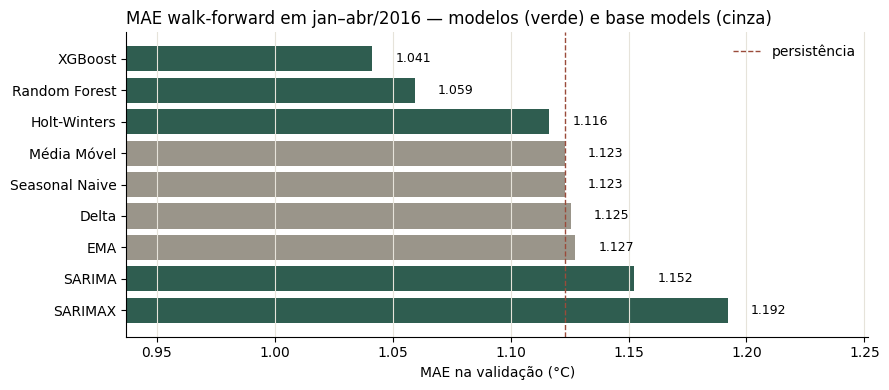

,Modelo,Parâmetro,MAE validação
0,XGBoost,"{'max_depth': 5, 'learning_rate': 0.03, 'n_est...",1.041
1,Random Forest,"{'max_depth': None, 'min_samples_split': 10, '...",1.059
2,Holt-Winters,tendência mul amortecida | sazonal add (m=365)...,1.116
3,Média Móvel,k=1,1.123
4,Seasonal Naive,s=1,1.123
5,Delta,janela=30,1.125
6,EMA,α=0.9,1.127
7,SARIMA,"(2, 0, 1)",1.152
8,SARIMAX,"(3, 1, 3) K=3 | ontem (lag 1)",1.192
9,Média Acumulada,-,6.207


In [53]:
resumo_validacao = (
    pd.DataFrame.from_dict(sumario, orient="index")
    .rename_axis("Modelo").reset_index()
    .sort_values("MAE validação").reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 4))
ordem = resumo_validacao[resumo_validacao["MAE validação"] < 3].iloc[::-1]
cores = [COR if m in ("SARIMA", "SARIMAX", "Holt-Winters", "Random Forest", "XGBoost") else "#9a958a"
         for m in ordem["Modelo"]]
ax.barh(ordem["Modelo"], ordem["MAE validação"], color=cores)
for i, v in enumerate(ordem["MAE validação"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
ax.axvline(persistencia_val["mae"], color="#9a4b3a", ls="--", lw=1, label="persistência")
ax.set_xlim(left=min(ordem["MAE validação"]) * 0.9)
ax.set_xlabel("MAE na validação (°C)")
ax.set_title("MAE walk-forward em jan–abr/2016 — modelos (verde) e base models (cinza)")
ax.legend(frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("img/validacao_modelos.png", dpi=150)
plt.show()

resumo_validacao[["Modelo", "Parâmetro", "MAE validação"]].round(3)

**Interpretação do resumo da validação:**
- **Abaixo da persistência (1,123 °C):** XGBoost (1,041), Random Forest (1,059) e Holt-Winters (1,116).
- **Acima dela:** SARIMA (1,152) e SARIMAX (1,192).
- **Faixa estreita:** do melhor ao pior modelo são 0,15 °C, e as árvores ficaram apenas 5% a 7% abaixo da persistência.
- **Otimismo da seleção:** as árvores foram escolhidas entre 108 e 384 configurações com base nos mesmos 121 dias. Quanto mais configurações se compara, mais o MAE de validação da vencedora tende a ser otimista em relação ao erro futuro.

### Os modelos só repetem o dia anterior?

Como os MAEs ficam perto do da persistência, vale checar se os modelos aprenderam algo além de "amanhã = hoje". Se um modelo só copiasse ontem, a variação prevista (previsão − temperatura de ontem) seria ≈ 0 e não teria relação com a variação real. A checagem usa as previsões de validação das configurações escolhidas.

In [54]:
previsores_escolhidos = {
    "SARIMA": prever_sarima(MELHOR_SARIMA),
    "SARIMAX": prever_sarimax(MELHOR_SARIMAX),
    "Holt-Winters": prever_hw(MELHOR_HW),
    "Random Forest": prever_arvore(fabrica_rf, MELHOR_RF["params"], MELHOR_RF["modo"]),
    "XGBoost": prever_arvore(fabrica_xgb, MELHOR_XGB["params"], MELHOR_XGB["modo"]),
}
previsoes_val = dict(zip(previsores_escolhidos, Parallel(n_jobs=-1)(
    delayed(walk_forward)(f, ORIGENS_VALIDACAO) for f in previsores_escolhidos.values())))

real = dados.loc[ORIGENS_VALIDACAO, "y"]
ontem = dados.loc[ORIGENS_VALIDACAO, "temp_lag1"]
var_real = real - ontem
print(f"Variação real média |y[t] - y[t-1]|: {var_real.abs().mean():.3f} °C")

linhas = []
for nome, r in previsoes_val.items():
    var_prev = r["previsao"] - ontem
    grande = var_real.abs() > 0.5
    linhas.append({
        "modelo": nome,
        "MAE validação": r["mae"],
        "|previsão - ontem| médio": var_prev.abs().mean(),
        "% dias ≠ ontem (> 0,1 °C)": (var_prev.abs() > 0.1).mean() * 100,
        "corr(var. prevista, var. real)": np.corrcoef(var_prev, var_real)[0, 1],
        "acerto da direção (|Δ| > 0,5 °C)": (np.sign(var_prev[grande]) == np.sign(var_real[grande])).mean() * 100,
    })
pd.DataFrame(linhas).sort_values("MAE validação").round(3)

Variação real média |y[t] - y[t-1]|: 1.123 °C


,modelo,MAE validação,|previsão - ontem| médio,"% dias ≠ ontem (> 0,1 °C)","corr(var. prevista, var. real)","acerto da direção (|Δ| > 0,5 °C)"
4,XGBoost,1.041,0.341,80.992,0.350,68.831
3,Random Forest,1.059,0.292,79.339,0.306,71.429
2,Holt-Winters,1.116,0.310,76.033,0.182,58.442
0,SARIMA,1.152,0.360,83.471,0.231,53.247
1,SARIMAX,1.192,0.568,86.777,0.358,53.247


**Interpretação:**
- **Os modelos não copiam ontem:**
  - XGBoost e Random Forest mudam a previsão em relação a ontem em ~80% dos dias.
  - A variação prevista tem correlação de 0,31 a 0,35 com a variação real.
  - Nos dias com variação acima de 0,5 °C, eles acertam a direção em 69% a 71% dos casos (o acaso daria 50%).
- **Mas ficam ancorados nele:** a variação prevista média é de 0,29 a 0,34 °C, contra 1,12 °C de variação real. Nas viradas bruscas (frentes frias, chuva), os modelos quase não se movem.
- **Por quê:** com informação fraca sobre o dia seguinte, ficar perto de ontem é o que minimiza o MAE.
- **Modelos estatísticos:** Holt-Winters, SARIMA e SARIMAX acertam a direção em 53% a 58%. O SARIMAX move bastante a previsão (0,57 °C em média), mas com pouca precisão na direção.

## Teste Final

Walk-forward nas **114 origens do bloco de teste** (01/01 a 24/04/2017), com as configurações escolhidas na validação **fixas**. Valem o mesmo horizonte (`h = 1`), a mesma janela expansiva e o mesmo reajuste a cada 7 dias. O treino na primeira origem vai de 31/01/2013 a 31/12/2016.

Para cada modelo ficam registrados os parâmetros, o tempo de execução, as previsões e os resíduos (real − previsto). A persistência entra como referência.

In [55]:
FINAIS = {
    "SARIMA": (prever_sarima(MELHOR_SARIMA), nome_sarima(MELHOR_SARIMA)),
    "SARIMAX": (prever_sarimax(MELHOR_SARIMAX), nome_cfg(MELHOR_SARIMAX)),
    "Holt-Winters": (prever_hw(MELHOR_HW), nome_hw(MELHOR_HW)),
    "Random Forest": (prever_arvore(fabrica_rf, MELHOR_RF["params"], MELHOR_RF["modo"]),
                      f"{MELHOR_RF['params']} | modo {MELHOR_RF['modo']}"),
    "XGBoost": (prever_arvore(fabrica_xgb, MELHOR_XGB["params"], MELHOR_XGB["modo"]),
                f"{MELHOR_XGB['params']} | modo {MELHOR_XGB['modo']}"),
    "Persistência": (prever_persistencia, "y[t-1]"),
}

execucoes = dict(zip(FINAIS, Parallel(n_jobs=-1)(
    delayed(walk_forward)(f, ORIGENS_TESTE) for f, _ in FINAIS.values())))

MODELOS = list(FINAIS)
resultados_teste = pd.concat([
    pd.DataFrame({"data": ORIGENS_TESTE, "modelo": m, "y_real": dados.loc[ORIGENS_TESTE, "y"].values,
                  "y_previsto": execucoes[m]["previsao"].values, "residuo": execucoes[m]["residuo"].values})
    for m in MODELOS
], ignore_index=True)

mae_teste = pd.DataFrame([
    {"base": "Temperatura (Delhi)", "modelo": m, "configuração": FINAIS[m][1],
     "MAE validação": sumario.get(m, {}).get("MAE validação", persistencia_val["mae"] if m == "Persistência" else np.nan),
     "MAE teste": execucoes[m]["mae"], "tempo teste (s)": execucoes[m]["tempo_s"]}
    for m in MODELOS
]).sort_values("MAE teste").reset_index(drop=True)
mae_teste["ranking"] = mae_teste["MAE teste"].rank(method="min").astype(int)

resultados_teste.to_csv("resultados_teste.csv", index=False)
mae_teste.to_csv("mae_temperatura.csv", index=False)
mae_teste[["ranking", "modelo", "MAE validação", "MAE teste", "tempo teste (s)", "configuração"]].round(3)

,ranking,modelo,MAE validação,MAE teste,tempo teste (s),configuração
0,1,SARIMAX,1.192,1.243,122.289,"SARIMAX(3, 1, 3) K=3 | ontem (lag 1)"
1,2,Holt-Winters,1.116,1.305,4.136,tendência mul amortecida | sazonal add (m=365)...
2,3,Random Forest,1.059,1.312,111.744,"{'max_depth': None, 'min_samples_split': 10, '..."
3,4,Persistência,1.123,1.314,0.020,y[t-1]
4,5,SARIMA,1.152,1.336,15.060,"SARIMA(2, 0, 1)"
5,6,XGBoost,1.041,1.343,19.278,"{'max_depth': 5, 'learning_rate': 0.03, 'n_est..."


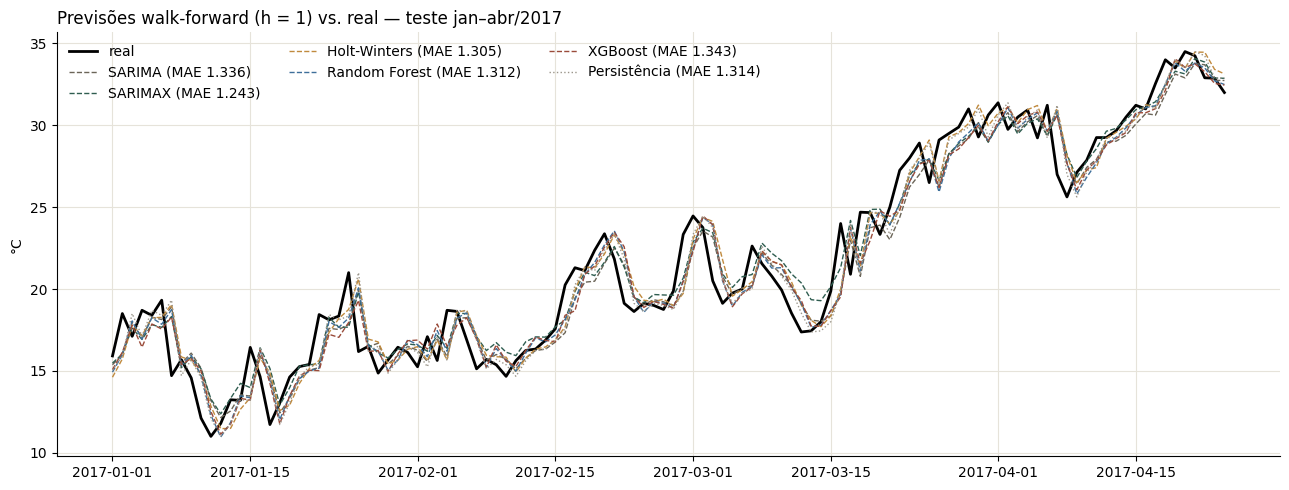

In [56]:
CORES_MODELOS = {"SARIMA": "#6b6558", "SARIMAX": "#2f5d50", "Holt-Winters": "#c08a3e",
                 "Random Forest": "#3e6f9a", "XGBoost": "#9a4b3a", "Persistência": "#9a958a"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ORIGENS_TESTE, dados.loc[ORIGENS_TESTE, "y"], color="black", lw=2, label="real")
for m in MODELOS:
    estilo = ":" if m == "Persistência" else "--"
    ax.plot(ORIGENS_TESTE, execucoes[m]["previsao"], color=CORES_MODELOS[m], lw=1, ls=estilo,
            label=f"{m} (MAE {execucoes[m]['mae']:.3f})")
ax.set_title("Previsões walk-forward (h = 1) vs. real — teste jan–abr/2017")
ax.set_ylabel("°C")
ax.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
plt.savefig("img/previsoes_teste.png", dpi=150)
plt.show()

**Interpretação do teste final:**
- **Ranking:**
  - 1º SARIMAX, com 1,243 °C (5,4% abaixo da persistência, 1,314 °C);
  - 2º Holt-Winters (1,305) e 3º Random Forest (1,312), praticamente empatados com a persistência;
  - SARIMA (1,336) e XGBoost (1,343) ficam acima dela.
- **A ordem da validação não se repetiu:** XGBoost e Random Forest lideraram a validação e não confirmaram no teste; o SARIMAX, pior na validação, foi o melhor no teste. Três fatores ajudam a explicar:
  1. As diferenças são pequenas: os seis cabem em 0,10 °C, e 121 dias de validação não bastam para ordená-los com segurança.
  2. Otimismo da seleção nas árvores (centenas de configurações escolhidas nos mesmos dias).
  3. O teste foi mais difícil: a persistência piorou de 1,123 para 1,314 °C.
- **Por que o SARIMAX venceu:** ele representa de forma explícita e suave o ciclo anual (F_S = 0,93) com Fourier e deixa a dinâmica de curto prazo para os termos ARIMA. É o mais preciso em janeiro, fevereiro e abril.
- **Limitação:** a diferença para a persistência (0,07 °C) não passou por teste de significância. Um teste de Diebold-Mariano seria o próximo passo.

## Análise dos Resíduos

Resíduos fora da amostra do bloco de teste (`y_real − y_previsto`): resíduo positivo significa que o modelo previu abaixo do real.
- **Gráfico no tempo e ACF:** mostram viés, padrões remanescentes e mudança de variabilidade.
- **Ljung-Box:** testa se há autocorrelação conjunta até o lag *k* (H0: resíduos sem autocorrelação). Com 114 pontos, usam-se os lags 7 e 14. Um p-valor baixo indica estrutura que o modelo não capturou. Um p-valor alto indica ausência de evidência de autocorrelação, não prova de independência.

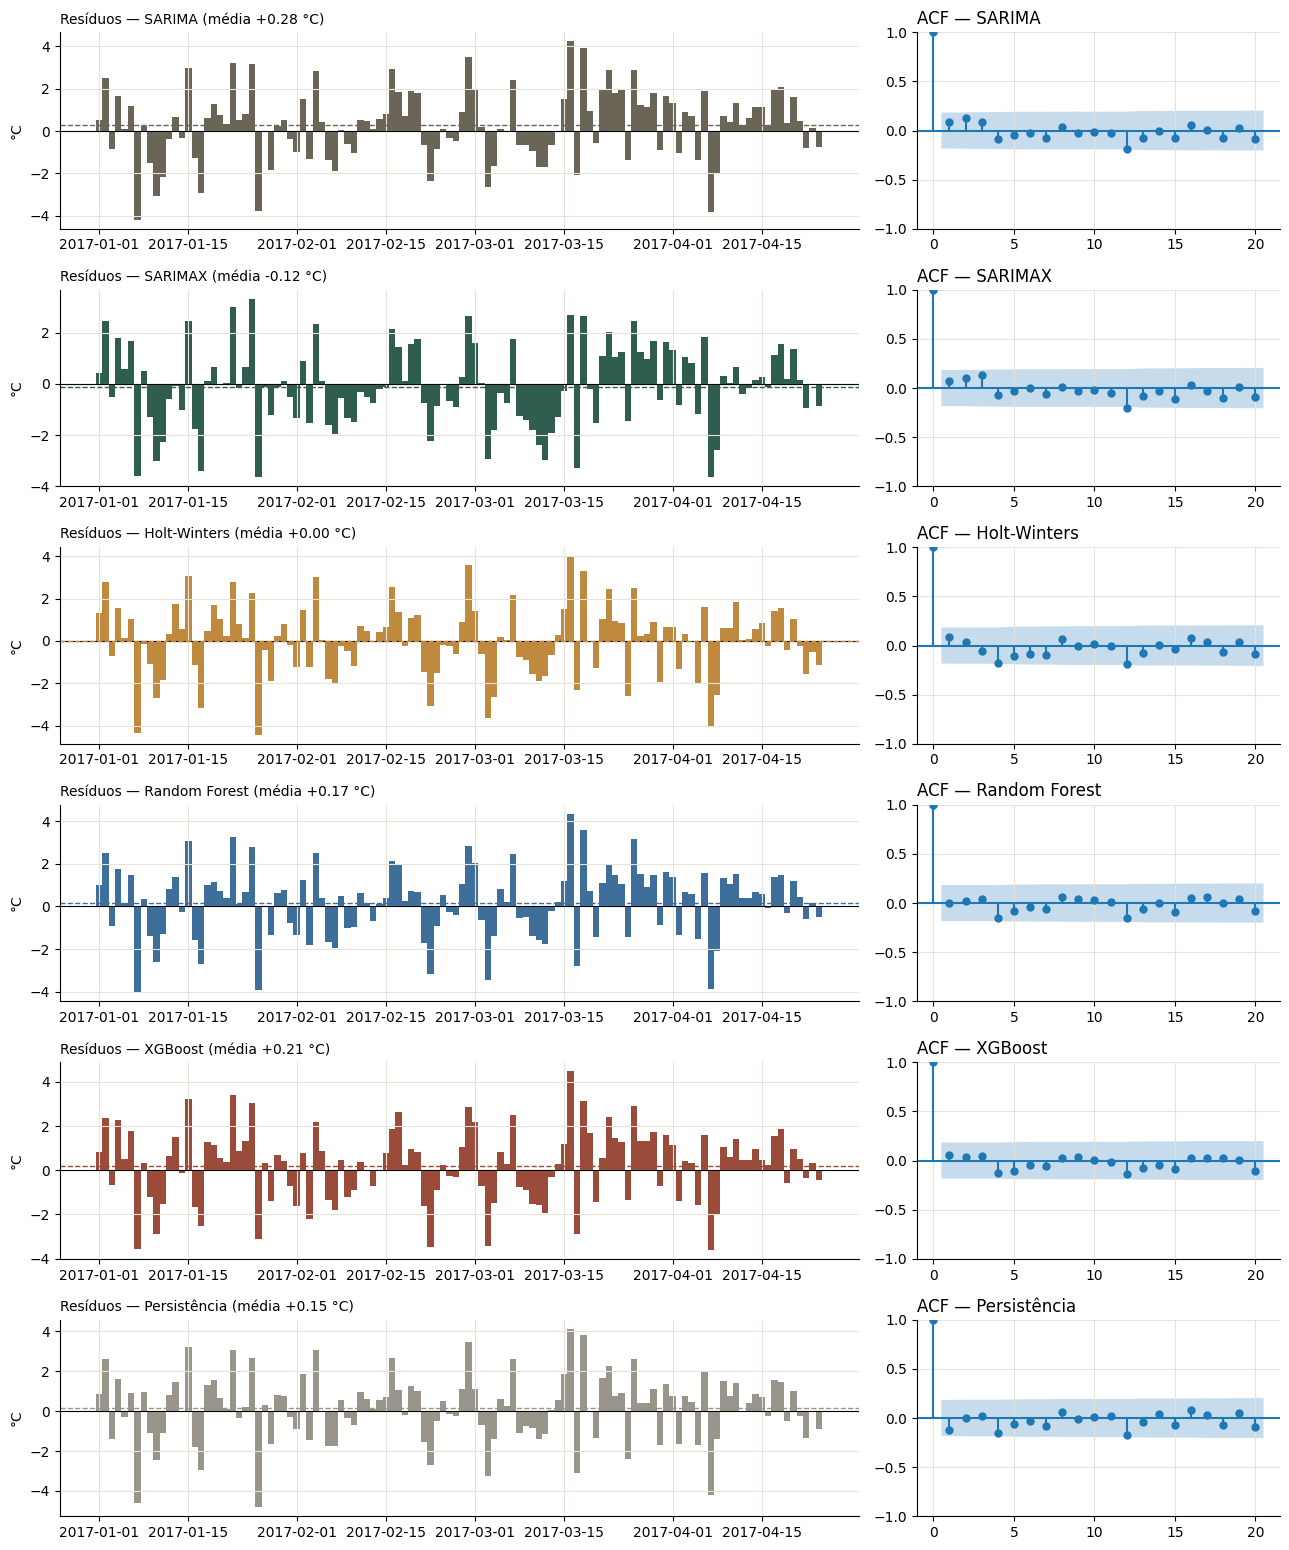

In [57]:
from statsmodels.stats.diagnostic import acorr_ljungbox

modelos_res = [m for m in MODELOS if m != "Persistência"] + ["Persistência"]
fig, axes = plt.subplots(len(modelos_res), 2, figsize=(13, 2.6 * len(modelos_res)),
                         gridspec_kw={"width_ratios": [2.2, 1]})
for i, m in enumerate(modelos_res):
    res = execucoes[m]["residuo"]
    axes[i, 0].bar(res.index, res.values, width=1, color=CORES_MODELOS[m])
    axes[i, 0].axhline(0, color="black", lw=0.8)
    axes[i, 0].axhline(res.mean(), color=CORES_MODELOS[m], lw=1, ls="--")
    axes[i, 0].set_title(f"Resíduos — {m} (média {res.mean():+.2f} °C)", fontsize=10)
    axes[i, 0].set_ylabel("°C")
    plot_acf(res.values, lags=20, ax=axes[i, 1], title=f"ACF — {m}")
plt.tight_layout()
plt.savefig("img/residuos.png", dpi=130)
plt.show()

In [58]:
linhas_res = []
for m in modelos_res:
    res = execucoes[m]["residuo"]
    lb = acorr_ljungbox(res.values, lags=[7, 14], return_df=True)
    p7, p14 = lb.loc[7, "lb_pvalue"], lb.loc[14, "lb_pvalue"]
    linhas_res.append({
        "modelo": m,
        "Ljung-Box lag 7": lb.loc[7, "lb_stat"], "p-valor lag 7": p7,
        "Ljung-Box lag 14": lb.loc[14, "lb_stat"], "p-valor lag 14": p14,
        "interpretação": "autocorrelação remanescente (p < 0,05)" if min(p7, p14) < 0.05
                         else "sem evidência de autocorrelação",
        "viés (média)": res.mean(),
        "dp": res.std(),
        "mín": res.min(), "máx": res.max(),
        "% dias superestimados": (res < 0).mean() * 100,
        "ACF lag 1": acf(res.values, nlags=1)[1],
    })
tabela_residuos = pd.DataFrame(linhas_res)
tabela_residuos.to_csv("ljung_box_temperatura.csv", index=False)
tabela_residuos.round(3)

,modelo,Ljung-Box lag 7,p-valor lag 7,Ljung-Box lag 14,p-valor lag 14,interpretação,viés (média),dp,mín,máx,% dias superestimados,ACF lag 1
0,SARIMA,5.814,0.562,11.546,0.643,sem evidência de autocorrelação,0.282,1.666,-4.203,4.245,37.719,0.087
1,SARIMAX,5.251,0.629,12.166,0.593,sem evidência de autocorrelação,-0.117,1.580,-3.657,3.331,54.386,0.076
2,Holt-Winters,8.512,0.290,14.410,0.420,sem evidência de autocorrelação,0.002,1.689,-4.440,4.000,44.737,0.085
3,Random Forest,4.455,0.726,8.947,0.834,sem evidência de autocorrelação,0.174,1.634,-4.028,4.343,39.474,0.001
4,XGBoost,4.624,0.706,8.471,0.863,sem evidência de autocorrelação,0.207,1.645,-3.606,4.478,38.596,0.054
5,Persistência,6.044,0.535,10.784,0.703,sem evidência de autocorrelação,0.149,1.685,-4.821,4.125,42.982,-0.123


In [59]:
# Variabilidade ao longo do teste: o erro muda conforme a época (inverno x subida da primavera)?
resultados_teste["mês"] = resultados_teste["data"].dt.month
(resultados_teste.assign(erro_abs=resultados_teste["residuo"].abs())
 .pivot_table(index="modelo", columns="mês", values="erro_abs", aggfunc="mean")
 .reindex(modelos_res).round(3))

mês,1,2,3,4
modelo,,,,
SARIMA,1.425,1.173,1.554,1.129
SARIMAX,1.330,1.084,1.563,0.902
Holt-Winters,1.453,1.183,1.462,1.052
Random Forest,1.449,1.139,1.541,1.043
XGBoost,1.490,1.160,1.617,1.013
Persistência,1.508,1.132,1.472,1.070


**Interpretação dos resíduos:**
- **Autocorrelação:** nenhum modelo deixou estrutura temporal. Todos os p-valores do Ljung-Box ficam acima de 0,29 nos lags 7 e 14, e as ACFs não têm picos fora da banda. O que sobra é a variação do dia, que os dados disponíveis não antecipam. Com 114 pontos, p alto indica ausência de evidência, não prova de independência.
- **Viés:**
  - SARIMA (+0,28 °C), XGBoost (+0,21) e Random Forest (+0,17) preveem abaixo do real: de 60% a 62% dos dias foram subestimados. O teste é a fase de subida da temperatura, e esses modelos chegam com atraso.
  - O Holt-Winters não tem viés (0,00).
  - O SARIMAX tem um viés pequeno no sentido oposto (−0,12), graças à curva sazonal explícita.
- **Variabilidade:**
  - O desvio-padrão vai de 1,58 (SARIMAX) a 1,69 °C, com extremos de cerca de ±4,5 °C nas viradas bruscas.
  - O erro é maior em janeiro (1,33 a 1,51 °C) e março (1,46 a 1,62 °C), com quedas bruscas de temperatura, e menor em abril (0,90 a 1,13 °C).
- **Persistência como contraste:** ela tem ACF de −0,12 no lag 1, porque depois de uma virada erra duas vezes seguidas em sentidos opostos. Os modelos eliminam esse padrão (ACF entre 0,00 e 0,09).

## Importância das Features

| Modelo | Método |
|---|---|
| Random Forest | importância nativa (redução de impureza) e Permutation Importance |
| XGBoost | *gain* e Permutation Importance |
| SARIMAX | coeficientes das exógenas: sinal, magnitude padronizada e significância |
| Holt-Winters | sem features: interpretação de nível, tendência e sazonalidade |

**Modelo final.** As árvores e o SARIMAX são reajustados em todo o histórico anterior ao teste (31/01/2013 a 31/12/2016), com os hiperparâmetros fixos. A permutação é avaliada no bloco de teste, no mesmo espaço de alvo do modelo (nível ou diferença), com o MAE como métrica.

**Permutação por grupo.** As features são muito correlacionadas entre si (9 lags e 8 janelas da mesma temperatura). Nesse caso, a importância individual se divide entre as colunas parecidas e subestima o grupo, como o slide da aula alerta. Por isso também se embaralham juntas todas as colunas de cada grupo: lags do alvo, janelas móveis, calendário, umidade e vento.

As variáveis externas aparecem destacadas em terracota.

In [60]:
from sklearn.inspection import permutation_importance

INDEX_PRE_TESTE = dados.index[dados.index < ORIGENS_TESTE[0]]
X_pre, X_te = dados.loc[INDEX_PRE_TESTE, FEATURE_COLS], dados.loc[ORIGENS_TESTE, FEATURE_COLS]

GRUPOS = {
    "lags do alvo": [c for c in FEATURE_COLS if c.startswith("temp_lag")] + ["temp_var1"],
    "janelas móveis": [c for c in FEATURE_COLS if c.startswith(("temp_media", "temp_dp", "temp_min", "temp_max"))],
    "calendário (dia do ano)": ["doy_sin", "doy_cos"],
    "umidade (defasada)": [c for c in FEATURE_COLS if c.startswith("humidity")],
    "vento (defasado)": [c for c in FEATURE_COLS if c.startswith("wind_speed")],
}
assert sorted(sum(GRUPOS.values(), [])) == sorted(FEATURE_COLS)
EXTERNAS_COLS = GRUPOS["umidade (defasada)"] + GRUPOS["vento (defasado)"]
COR_EXT = "#9a4b3a"


def permutacao_grupos(modelo, X, y, n_repeats=30, seed=42):
    rng = np.random.default_rng(seed)
    base_mae = np.mean(np.abs(y - modelo.predict(X)))
    linhas = []
    for grupo, cols in GRUPOS.items():
        aumentos = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].values[rng.permutation(len(X))]   # mesma permutação para o grupo todo
            aumentos.append(np.mean(np.abs(y - modelo.predict(Xp))) - base_mae)
        linhas.append({"grupo": grupo, "aumento do MAE": np.mean(aumentos), "dp": np.std(aumentos)})
    return pd.DataFrame(linhas).sort_values("aumento do MAE", ascending=False)


def importancias_arvore(nome, fabrica, cfg, nativa_nome, nativa_fn):
    modelo = fabrica(cfg["params"]).fit(X_pre, alvo(dados.loc[INDEX_PRE_TESTE], cfg["modo"]))
    y_te = alvo(dados.loc[ORIGENS_TESTE], cfg["modo"])
    perm = permutation_importance(modelo, X_te, y_te, scoring="neg_mean_absolute_error",
                                  n_repeats=30, random_state=42, n_jobs=-1)
    tabela = pd.DataFrame({
        nativa_nome: nativa_fn(modelo),
        "permutação (aumento do MAE)": perm.importances_mean,
        "permutação dp": perm.importances_std,
    }, index=FEATURE_COLS).sort_values("permutação (aumento do MAE)", ascending=False)
    grupos = permutacao_grupos(modelo, X_te, y_te)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1, 0.9]})
    for ax, col in zip(axes[:2], [nativa_nome, "permutação (aumento do MAE)"]):
        t = tabela.sort_values(col).tail(15)
        ax.barh(t.index, t[col], color=[COR_EXT if c in EXTERNAS_COLS else COR for c in t.index])
        ax.set_title(f"{nome} — {col}", fontsize=10)
        ax.grid(axis="y", visible=False)
    g = grupos.iloc[::-1]
    axes[2].barh(g["grupo"], g["aumento do MAE"], xerr=g["dp"],
                 color=[COR_EXT if "defasad" in x else COR for x in g["grupo"]])
    axes[2].set_title(f"{nome} — permutação por grupo (aumento do MAE, °C)", fontsize=10)
    axes[2].grid(axis="y", visible=False)
    plt.tight_layout()
    plt.savefig(f"img/importancia_{nome.lower().replace(' ', '_')}.png", dpi=130)
    plt.show()
    return modelo, tabela, grupos

### Random Forest

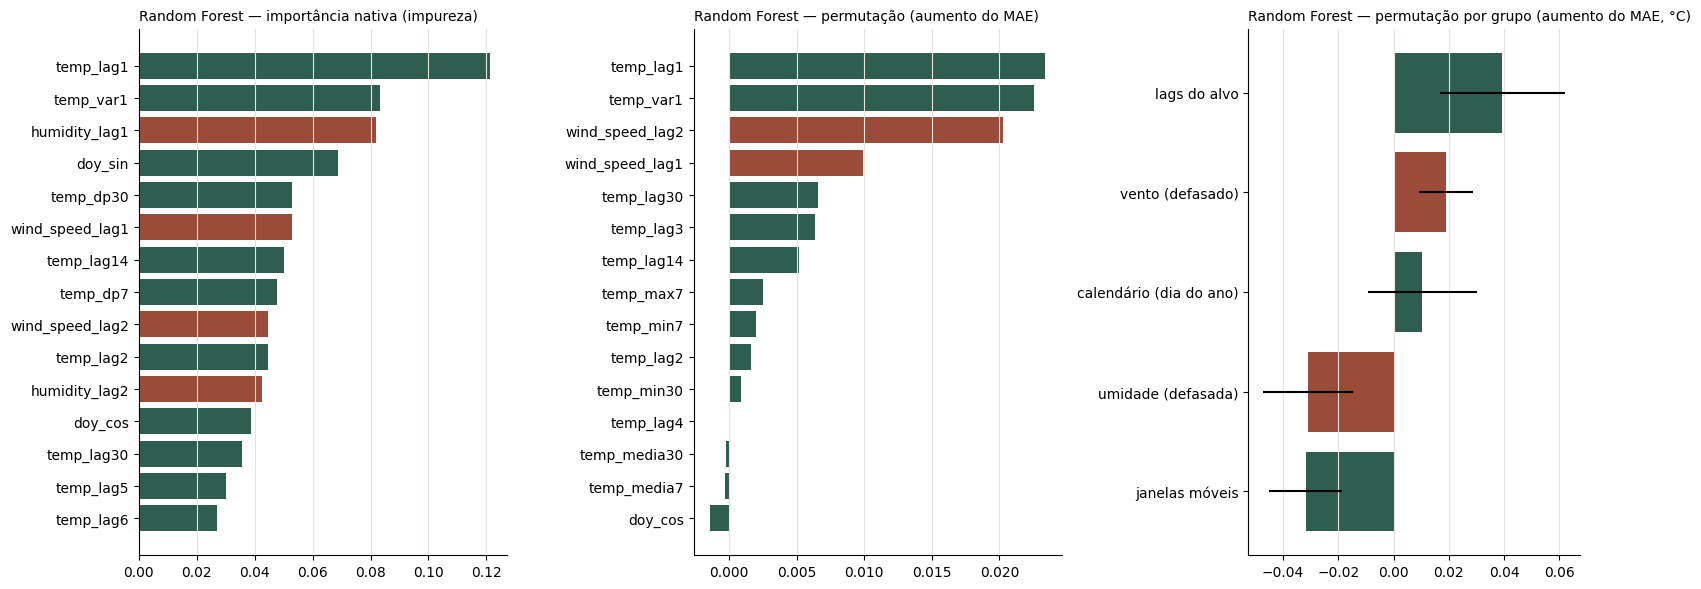

,grupo,aumento do MAE,dp
0,lags do alvo,0.0394,0.0227
4,vento (defasado),0.0190,0.0097
2,calendário (dia do ano),0.0104,0.0198
3,umidade (defasada),-0.0310,0.0161
1,janelas móveis,-0.0319,0.0132


,importância nativa (impureza),permutação (aumento do MAE),permutação dp
temp_lag1,0.1211,0.0234,0.0217
temp_var1,0.0831,0.0225,0.0225
wind_speed_lag2,0.0448,0.0203,0.0079
wind_speed_lag1,0.0528,0.0099,0.0120
temp_lag30,0.0356,0.0066,0.0047
temp_lag3,0.0242,0.0063,0.0022
temp_lag14,0.0502,0.0052,0.0059
temp_max7,0.0198,0.0025,0.0014
temp_min7,0.0192,0.0020,0.0011
temp_lag2,0.0447,0.0016,0.0099


In [61]:
rf_final, imp_rf, grupos_rf = importancias_arvore(
    "Random Forest", fabrica_rf, MELHOR_RF, "importância nativa (impureza)",
    lambda m: m.feature_importances_)
display(grupos_rf.round(4))
imp_rf.head(12).round(4)

### XGBoost

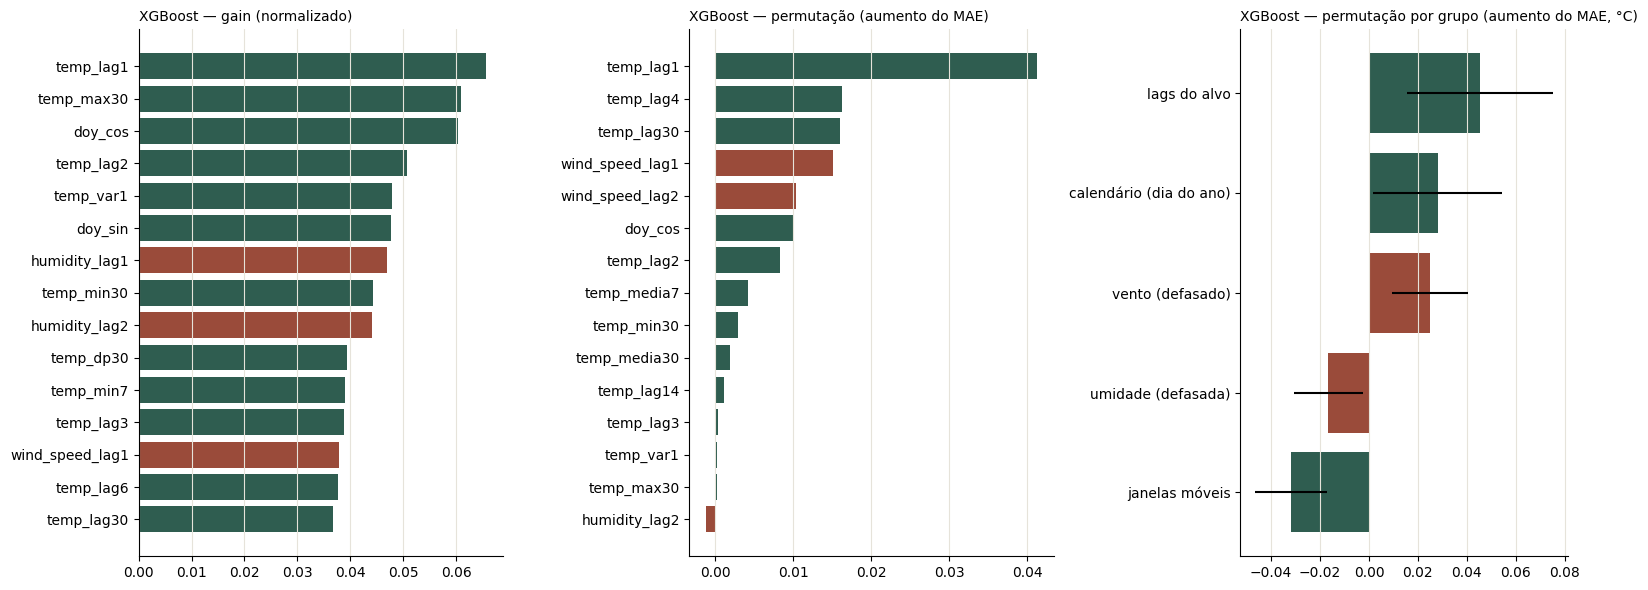

,grupo,aumento do MAE,dp
0,lags do alvo,0.0455,0.0299
2,calendário (dia do ano),0.0281,0.0263
4,vento (defasado),0.0250,0.0156
3,umidade (defasada),-0.0167,0.0140
1,janelas móveis,-0.0319,0.0146


,gain (normalizado),permutação (aumento do MAE),permutação dp
temp_lag1,0.0656,0.0413,0.0270
temp_lag4,0.0334,0.0163,0.0073
temp_lag30,0.0368,0.0160,0.0095
wind_speed_lag1,0.0378,0.0151,0.0137
wind_speed_lag2,0.0325,0.0104,0.0064
doy_cos,0.0604,0.0101,0.0209
temp_lag2,0.0508,0.0083,0.0166
temp_media7,0.0349,0.0042,0.0018
temp_min30,0.0444,0.0029,0.0010
temp_media30,0.0360,0.0019,0.0027


In [62]:
def gain_xgb(modelo):
    gain = modelo.get_booster().get_score(importance_type="gain")
    total = sum(gain.values())
    return [gain.get(c, 0.0) / total for c in FEATURE_COLS]


xgb_final, imp_xgb, grupos_xgb = importancias_arvore(
    "XGBoost", fabrica_xgb, MELHOR_XGB, "gain (normalizado)", gain_xgb)
display(grupos_xgb.round(4))
imp_xgb.head(12).round(4)

### SARIMAX — coeficientes das exógenas

Ajuste final em todo o histórico anterior ao teste. A **magnitude padronizada** (coeficiente × desvio-padrão da variável) mostra quantos °C a temperatura prevista muda quando a variável sobe um desvio-padrão. Isso permite comparar umidade (em %) com vento (em km/h).

In [63]:
res_sarimax_final = ajustar_sarimax(INDEX_PRE_TESTE, MELHOR_SARIMAX)
nomes_exog = ([f"fourier_{f}{k}" for k in range(1, MELHOR_SARIMAX["K"] + 1) for f in ("sin", "cos")]
              + EXOG_SARIMAX[MELHOR_SARIMAX["exog"]])
X_sarimax = pd.DataFrame(matriz_exog(INDEX_PRE_TESTE, MELHOR_SARIMAX), columns=nomes_exog)

coef_final = pd.DataFrame({"coeficiente": res_sarimax_final.params, "erro-padrão": res_sarimax_final.bse,
                           "p-valor": res_sarimax_final.pvalues}, index=res_sarimax_final.param_names)
coef_final.index = [nomes_exog[int(i[1:]) - 1] if i.startswith("x") and i[1:].isdigit() else i
                    for i in coef_final.index]
coef_final["magnitude padronizada (°C por dp)"] = [
    coef_final.loc[i, "coeficiente"] * X_sarimax[i].std() if i in X_sarimax else np.nan for i in coef_final.index]
coef_final["sinal"] = np.sign(coef_final["coeficiente"]).map({1.0: "+", -1.0: "−", 0.0: "0"})
coef_final["significativo (5%)"] = coef_final["p-valor"] < 0.05
print(nome_cfg(MELHOR_SARIMAX))
coef_final.round(4)

SARIMAX(3, 1, 3) K=3 | ontem (lag 1)


,coeficiente,erro-padrão,p-valor,magnitude padronizada (°C por dp),sinal,significativo (5%)
fourier_sin1,-0.5546,0.2750,0.0437,-0.3957,−,True
fourier_cos1,-9.3108,0.2559,0.0000,-6.5263,−,True
fourier_sin2,-1.6735,0.2251,0.0000,-1.1886,−,True
fourier_cos2,-2.4916,0.2064,0.0000,-1.7545,−,True
fourier_sin3,0.7380,0.1894,0.0001,0.5218,+,True
fourier_cos3,0.0337,0.1985,0.8652,0.0238,+,False
humidity_lag1,0.0034,0.0059,0.5673,0.0563,+,False
wind_speed_lag1,-0.0261,0.0109,0.0165,-0.1193,−,True
ar.L1,-0.0800,0.0565,0.1569,NaN,−,False
ar.L2,-0.4013,0.0477,0.0000,NaN,−,True


### Holt-Winters — componentes

O Holt-Winters não tem features. A interpretação é feita pelos componentes ajustados (nível, tendência e sazonalidade) e pelos parâmetros de suavização: α alto indica que o nível segue de perto a temperatura recente; γ baixo indica um perfil sazonal estável.

tendência mul amortecida | sazonal add (m=365) | init fourier | γ 0.05
{'smoothing_level': 0.7704, 'smoothing_trend': 0.0, 'smoothing_seasonal': 0.05, 'damping_trend': 0.995}


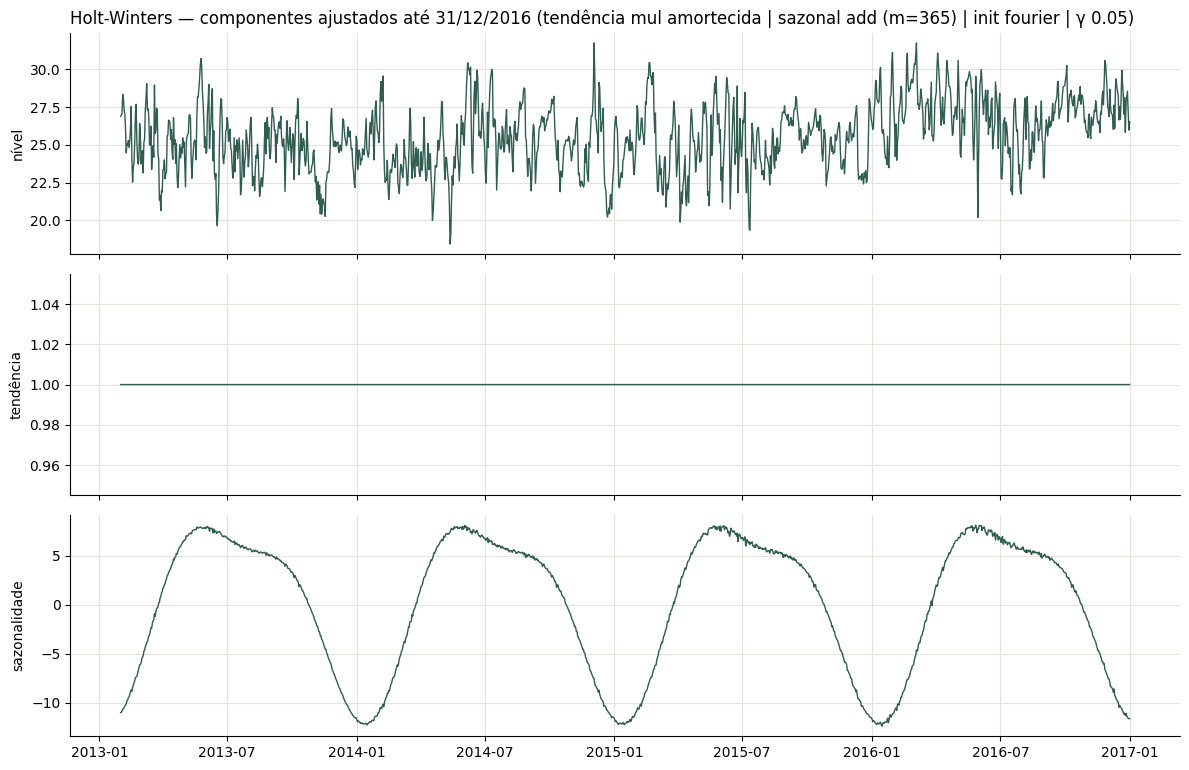

In [64]:
y_pre = dados.loc[INDEX_PRE_TESTE, "y"].asfreq("D")
hw_final = ajustar_hw(y_pre, MELHOR_HW, iniciais=estados_iniciais(y_pre, MELHOR_HW))
print(nome_hw(MELHOR_HW))
print({k: round(float(hw_final.params[k]), 4) for k in PARAMS_SUAVIZACAO if pd.notna(hw_final.params.get(k))})

componentes = {"nível": hw_final.level}
if MELHOR_HW["trend"]:
    componentes["tendência"] = hw_final.trend
if MELHOR_HW["seasonal"]:
    componentes["sazonalidade"] = hw_final.season
fig, axes = plt.subplots(len(componentes), 1, figsize=(12, 2.6 * len(componentes)), sharex=True, squeeze=False)
for ax, (nome, serie) in zip(axes[:, 0], componentes.items()):
    ax.plot(serie.index, serie, color=COR, lw=1)
    ax.set_ylabel(nome)
axes[0, 0].set_title(f"Holt-Winters — componentes ajustados até 31/12/2016 ({nome_hw(MELHOR_HW)})")
plt.tight_layout()
plt.savefig("img/componentes_hw.png", dpi=130)
plt.show()

**Interpretação da importância das features:**
- **Lags do alvo:** é o grupo que mais pesa nas duas árvores (+0,039 °C no RF e +0,046 no XGBoost quando embaralhado), com destaque para a temperatura de ontem.
- **Vento de ontem: a única externa útil nos três modelos.**
  - No RF e no XGBoost, embaralhar o vento aumenta o MAE (+0,019 e +0,025 °C).
  - No SARIMAX, o coeficiente é significativo e negativo (−0,12 °C por dp, p = 0,017): mais vento hoje antecede um dia seguinte um pouco mais frio, coerente com a chegada de frentes.
- **A umidade não ajudou no teste:**
  - Embaralhá-la *reduz* o MAE das árvores (−0,031 e −0,017), e o coeficiente no SARIMAX não é significativo (p = 0,57).
  - A correlação de −0,57 com a temperatura é, em boa parte, sazonal, e essa informação já chega pelo calendário e pelos lags.
  - As janelas móveis seguem o mesmo padrão (−0,032 nas duas árvores): repetem o que os lags já informam.
- **Calendário:** pesa mais no XGBoost (+0,028) do que no RF (+0,010). No SARIMAX, o 1º harmônico anual domina: −6,5 °C por dp, contra −0,12 do vento.
- **Holt-Winters:**
  - α = 0,77: o nível segue a temperatura recente.
  - β = 0 e φ = 0,995: tendência praticamente constante.
  - γ = 0,05: perfil sazonal estável.
- **Disponibilidade:** todas as externas entram defasadas (ontem e anteontem), medidas antes da origem da previsão. Nenhum modelo usa a umidade ou o vento do dia previsto.
- **Uso destes resultados:** eles vêm do bloco de teste e servem só para interpretar. Tirar a umidade ou as janelas com base neles seria usar o teste para decidir; essa escolha, se for feita, deve passar pela validação.

## Conclusão

- **Melhor modelo:** o **SARIMAX(3,1,3) com Fourier anual (K = 3) e externas de ontem** teve o menor MAE no teste (1,243 °C contra 1,314 °C da persistência), além dos resíduos menos dispersos e menos enviesados. Ele vence por representar de forma explícita o ciclo anual, a característica dominante da série.
- **Limitações:**
  - Com h = 1, todos os modelos ficam a menos de 0,1 °C da persistência, e as viradas bruscas concentram os maiores erros.
  - A ordem entre os modelos foi instável entre validação e teste.
  - Há só 4 ciclos anuais, o que inviabiliza m = 365 e torna a sazonalidade diária ruidosa.
  - O teste cobre só jan–abr.
  - Parte do grid do SARIMAX não convergiu.
- **Ajustes metodológicos:**
  - exclusão de `meanpressure`;
  - sazonalidade anual tratada por Fourier (SARIMAX) e por inicialização suave no Holt-Winters;
  - árvores no modo diferença;
  - externas só defasadas, das quais só o vento mostrou valor.